# EEG Eye State Classification

End-to-end pipeline: data loading → preprocessing → feature engineering → frequency analysis → dimensionality reduction → ML models → DL models → final comparison.

Dataset: **EEG Eye State** (14 EMOTIV channels + binary `eyeDetection` label, 128 Hz)


In [1]:
# pip install numpy pandas matplotlib seaborn scipy scikit-learn xgboost torch

import sys, os, time, warnings, math
from collections import defaultdict
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq
from scipy.signal import welch, spectrogram as scipy_spectrogram, butter, filtfilt
from scipy.stats import skew, kurtosis, ttest_ind
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve,
    classification_report, silhouette_score, davies_bouldin_score,
    calinski_harabasz_score)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
warnings.filterwarnings('ignore')

try:
    import yaml; HAS_YAML = True
except ImportError:
    HAS_YAML = False
try:
    from umap import UMAP; HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
try:
    from xgboost import XGBClassifier; HAS_XGB = True
except ImportError:
    HAS_XGB = False
    warnings.warn('xgboost not found — XGBoost model will be skipped.')


## Configuration & Constants

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PLOT_DIR = 'analysis-plots'
DATA_FILE = 'eeg_data_og.csv'
SAMPLING_RATE = 128
FEATURE_COLUMNS = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']
TARGET = 'eyeDetection'
RANDOM_STATE = 42
EYE_MAP = {0: 'Open', 1: 'Closed'}
SEQ_LEN = 64
PATCH_SIZE = 8
PATCH_STRIDE = 4
DL_EPOCHS = 25
DL_BATCH = 128
DL_LR = 0.001
ENS_TRIALS = 3000
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

HEMI_PAIRS = [('AF3','AF4'),('F7','F8'),('F3','F4'),('FC5','FC6'),
              ('T7','T8'),('P7','P8'),('O1','O2')]
FREQ_BANDS = {'Delta':(0.5,4),'Theta':(4,8),'Alpha':(8,12),
              'Beta':(12,30),'Gamma':(30,64)}
BAND_COLORS = ['#8B0000','#FF4500','#FFD700','#00CED1','#9370DB']
ELECTRODE_INFO = [
    ('AF3','Anterior Frontal Left','Prefrontal Cortex','Executive function, attention'),
    ('F7','Frontal Left Lateral','Left Temporal-Frontal','Language processing'),
    ('F3','Frontal Left','Left Frontal Lobe','Motor planning, positive affect'),
    ('FC5','Fronto-Central Left','Left Motor-Frontal','Motor preparation'),
    ('T7','Temporal Left','Left Temporal Lobe','Auditory processing, memory'),
    ('P7','Parietal Left','Left Parietal-Temporal','Visual-spatial processing'),
    ('O1','Occipital Left','Left Visual Cortex','Visual processing'),
    ('O2','Occipital Right','Right Visual Cortex','Visual processing'),
    ('P8','Parietal Right','Right Parietal-Temporal','Spatial attention'),
    ('T8','Temporal Right','Right Temporal Lobe','Face / emotion recognition'),
    ('FC6','Fronto-Central Right','Right Motor-Frontal','Motor preparation'),
    ('F4','Frontal Right','Right Frontal Lobe','Motor planning, negative affect'),
    ('F8','Frontal Right Lateral','Right Temporal-Frontal','Emotion, social cognition'),
    ('AF4','Anterior Frontal Right','Prefrontal Cortex','Executive function, attention'),
]

CONFIG = {}
_config_path = os.path.join(os.getcwd(), 'config.yaml')
if HAS_YAML and os.path.exists(_config_path):
    with open(_config_path) as _cf:
        CONFIG = yaml.safe_load(_cf) or {}
    PLOT_DIR   = CONFIG.get('paths', {}).get('plot_dir',    PLOT_DIR)
    DATA_FILE  = CONFIG.get('paths', {}).get('data_file',   DATA_FILE)
    SAMPLING_RATE = CONFIG.get('data', {}).get('sampling_rate', SAMPLING_RATE)
    RANDOM_STATE  = CONFIG.get('data', {}).get('random_state',  RANDOM_STATE)

os.makedirs(PLOT_DIR, exist_ok=True)
print(f'Device: {DEVICE}  |  Plot dir: {PLOT_DIR}')


Device: cpu  |  Plot dir: analysis-plots


## Utility Helpers

In [3]:
def progress(msg):
    print(msg, flush=True)

def save_fig(name):
    path = f'{PLOT_DIR}/{name}'
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close('all')
    return path


## Step 1 — Data Loading & Description

Load the raw CSV and produce a per-channel statistical summary alongside electrode metadata.


In [4]:
def section_data_description(df):
    _elec_map = {e[0]: e for e in ELECTRODE_INFO}
    combined_rows = []
    for ch in FEATURE_COLUMNS:
        e = _elec_map.get(ch, (ch, '—', '—', '—'))
        combined_rows.append([ch, 'Continuous (float64)', e[1], e[2], e[3]])
    desc = df[FEATURE_COLUMNS].describe().T
    rows = []
    for ch in FEATURE_COLUMNS:
        r = desc.loc[ch]
        mode_val = df[ch].mode().iloc[0] if not df[ch].mode().empty else float('nan')
        rows.append([ch, int(r['count']), f"{r['mean']:.2f}", f"{r['std']:.2f}",
                     f"{r['min']:.2f}", f"{r['25%']:.2f}", f"{r['50%']:.2f}",
                     f"{r['75%']:.2f}", f"{r['max']:.2f}", f'{mode_val:.2f}'])
    vc = df[TARGET].value_counts()
    print('Class counts:', vc.to_dict())
    return pd.DataFrame(rows, columns=['Channel','Count','Mean','Std','Min','Q1','Median','Q3','Max','Mode'])

# ── Load data & run section ──────────────────────────────────────────────
progress('[1/12] Loading data ...')
df = pd.read_csv(DATA_FILE)
desc_df = section_data_description(df)
display(desc_df)


[1/12] Loading data ...
Class counts: {0: 8257, 1: 6723}


,Channel,Count,Mean,Std,Min,Q1,Median,Q3,Max,Mode
0,AF3,14980,4321.92,2492.07,1030.77,4280.51,4294.36,4311.79,309231.00,4291.79
1,F7,14980,4009.77,45.94,2830.77,3990.77,4005.64,4023.08,7804.62,4003.59
2,F3,14980,4264.02,44.43,1040.00,4250.26,4262.56,4270.77,6880.51,4263.59
3,FC5,14980,4164.95,5216.40,2453.33,4108.21,4120.51,4132.31,642564.00,4122.56
4,T7,14980,4341.74,34.74,2089.74,4331.79,4338.97,4347.18,6474.36,4332.31
5,P7,14980,4644.02,2924.79,2768.21,4611.79,4617.95,4626.67,362564.00,4616.41
6,O1,14980,4110.40,4600.93,2086.15,4057.95,4070.26,4083.59,567179.00,4072.31
7,O2,14980,4616.06,29.29,4567.18,4604.62,4613.33,4624.10,7264.10,4610.77
8,P8,14980,4218.83,2136.41,1357.95,4190.77,4199.49,4209.23,265641.00,4196.92
9,T8,14980,4231.32,38.05,1816.41,4220.51,4229.23,4239.49,6674.36,4224.62


## Step 2 — Data Imputation

Check for missing values; fill any gaps with per-channel median.


In [5]:
def section_data_imputation(df):
    total_missing = df.isnull().sum().sum()
    if total_missing == 0:
        print('No missing values found.')
    else:
        rows = [[ch, int(df[ch].isnull().sum())] for ch in FEATURE_COLUMNS
                if df[ch].isnull().any()]
        print('Columns with missing values:', rows)
        for col in FEATURE_COLUMNS:
            if df[col].isnull().any():
                df[col] = df[col].fillna(df[col].median())
    return df

# ── Run section ─────────────────────────────────────────────────────────
progress('[2/12] Data imputation ...')
df = section_data_imputation(df)


[2/12] Data imputation ...
No missing values found.


## Step 3 — Raw Data Visualisation

Class balance bar chart, correlation heatmap, box plots, histograms, and violin plots for the unprocessed signal.


[3/12] Visualising raw data ...


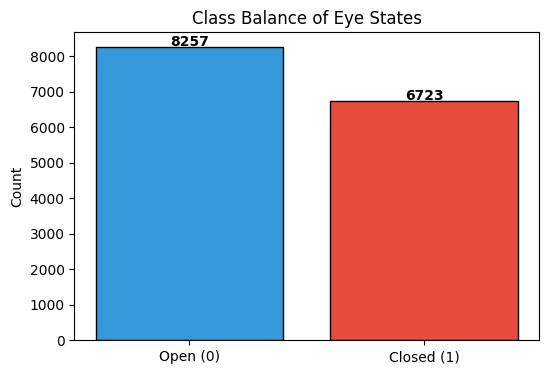

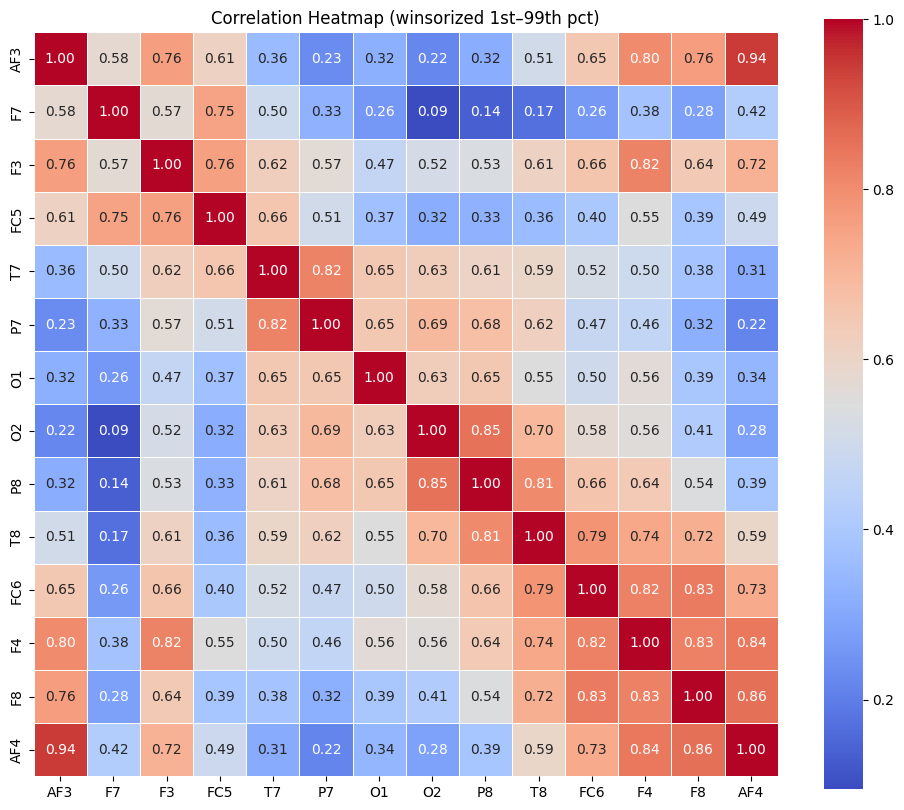

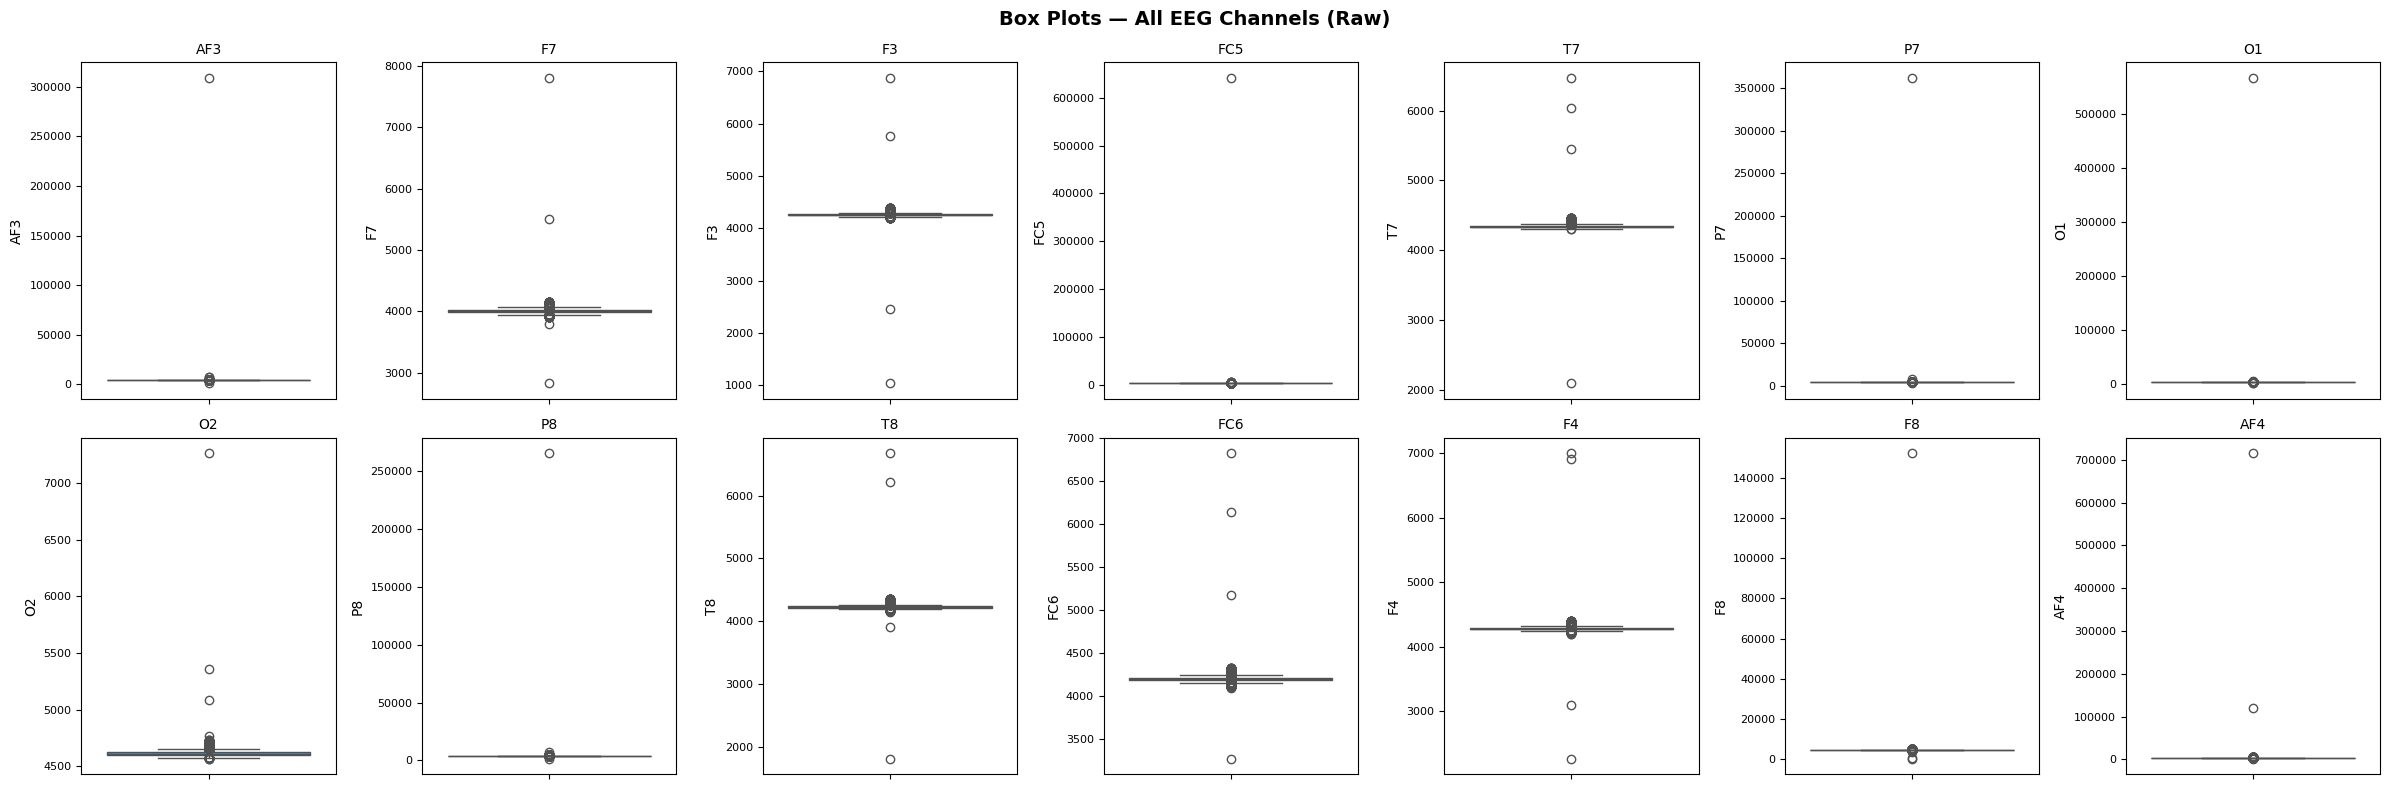

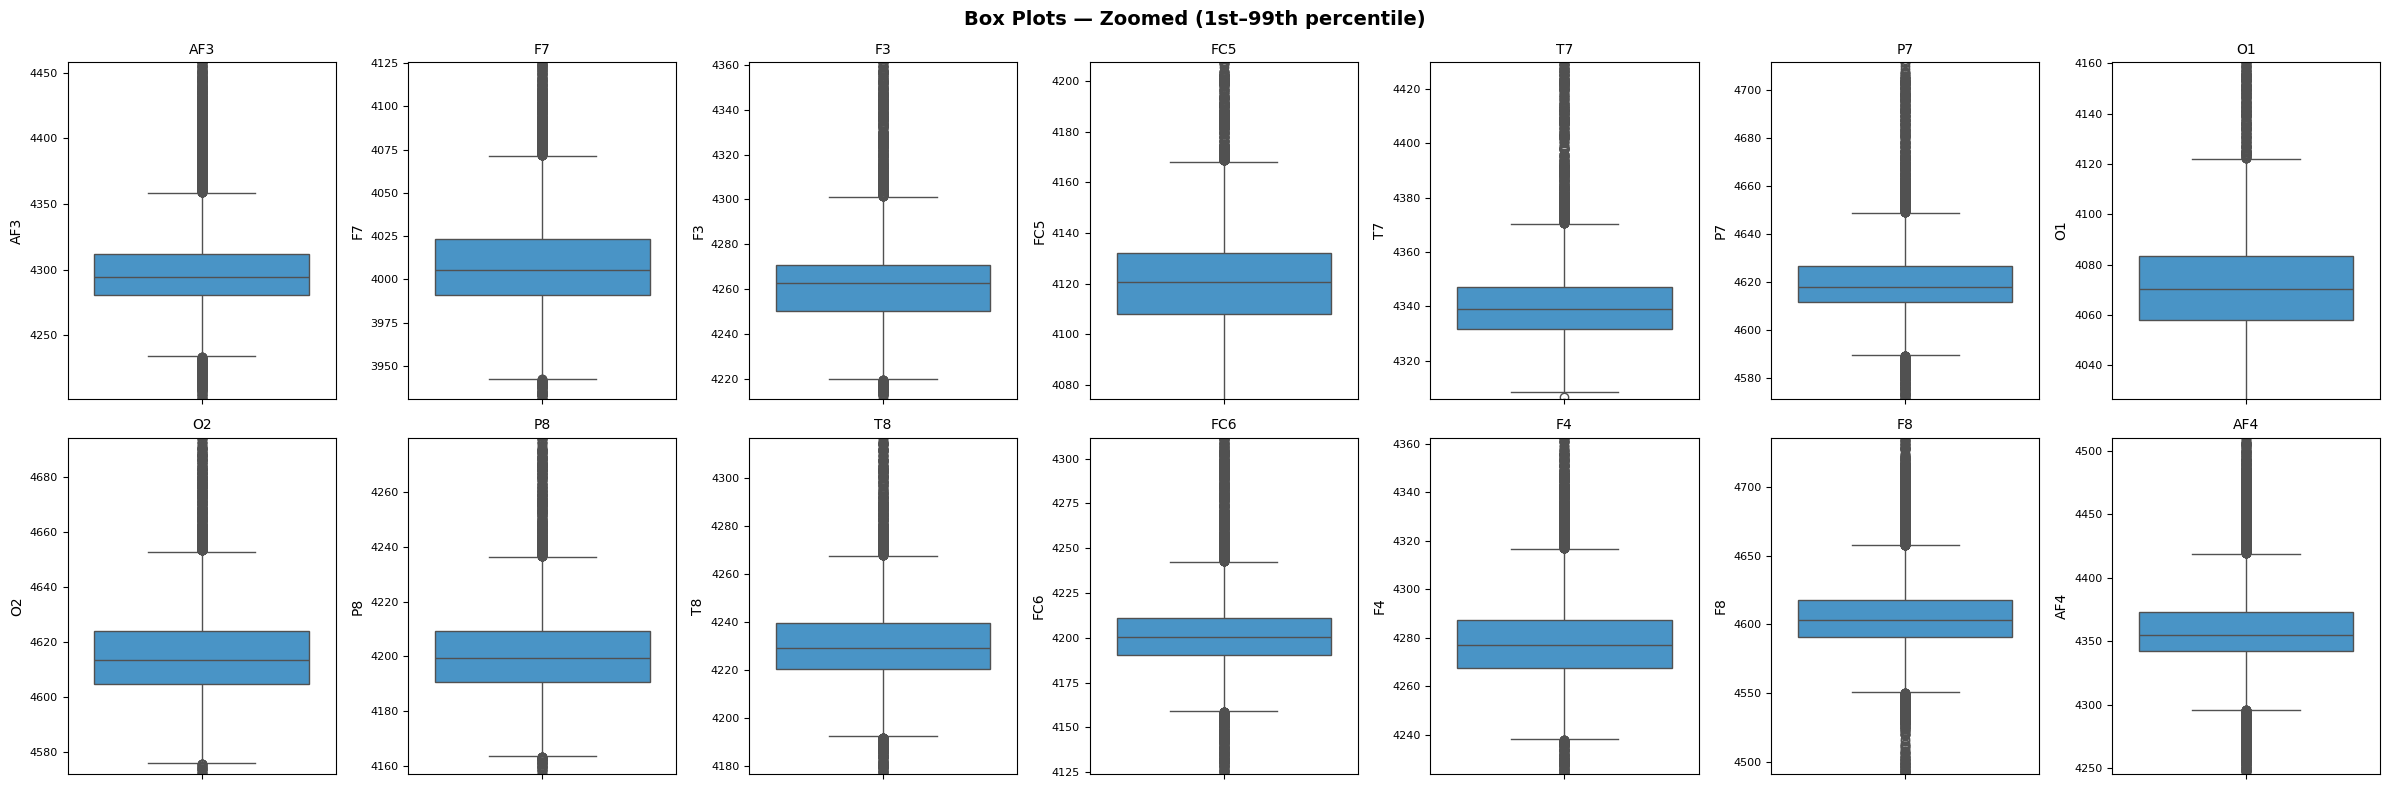

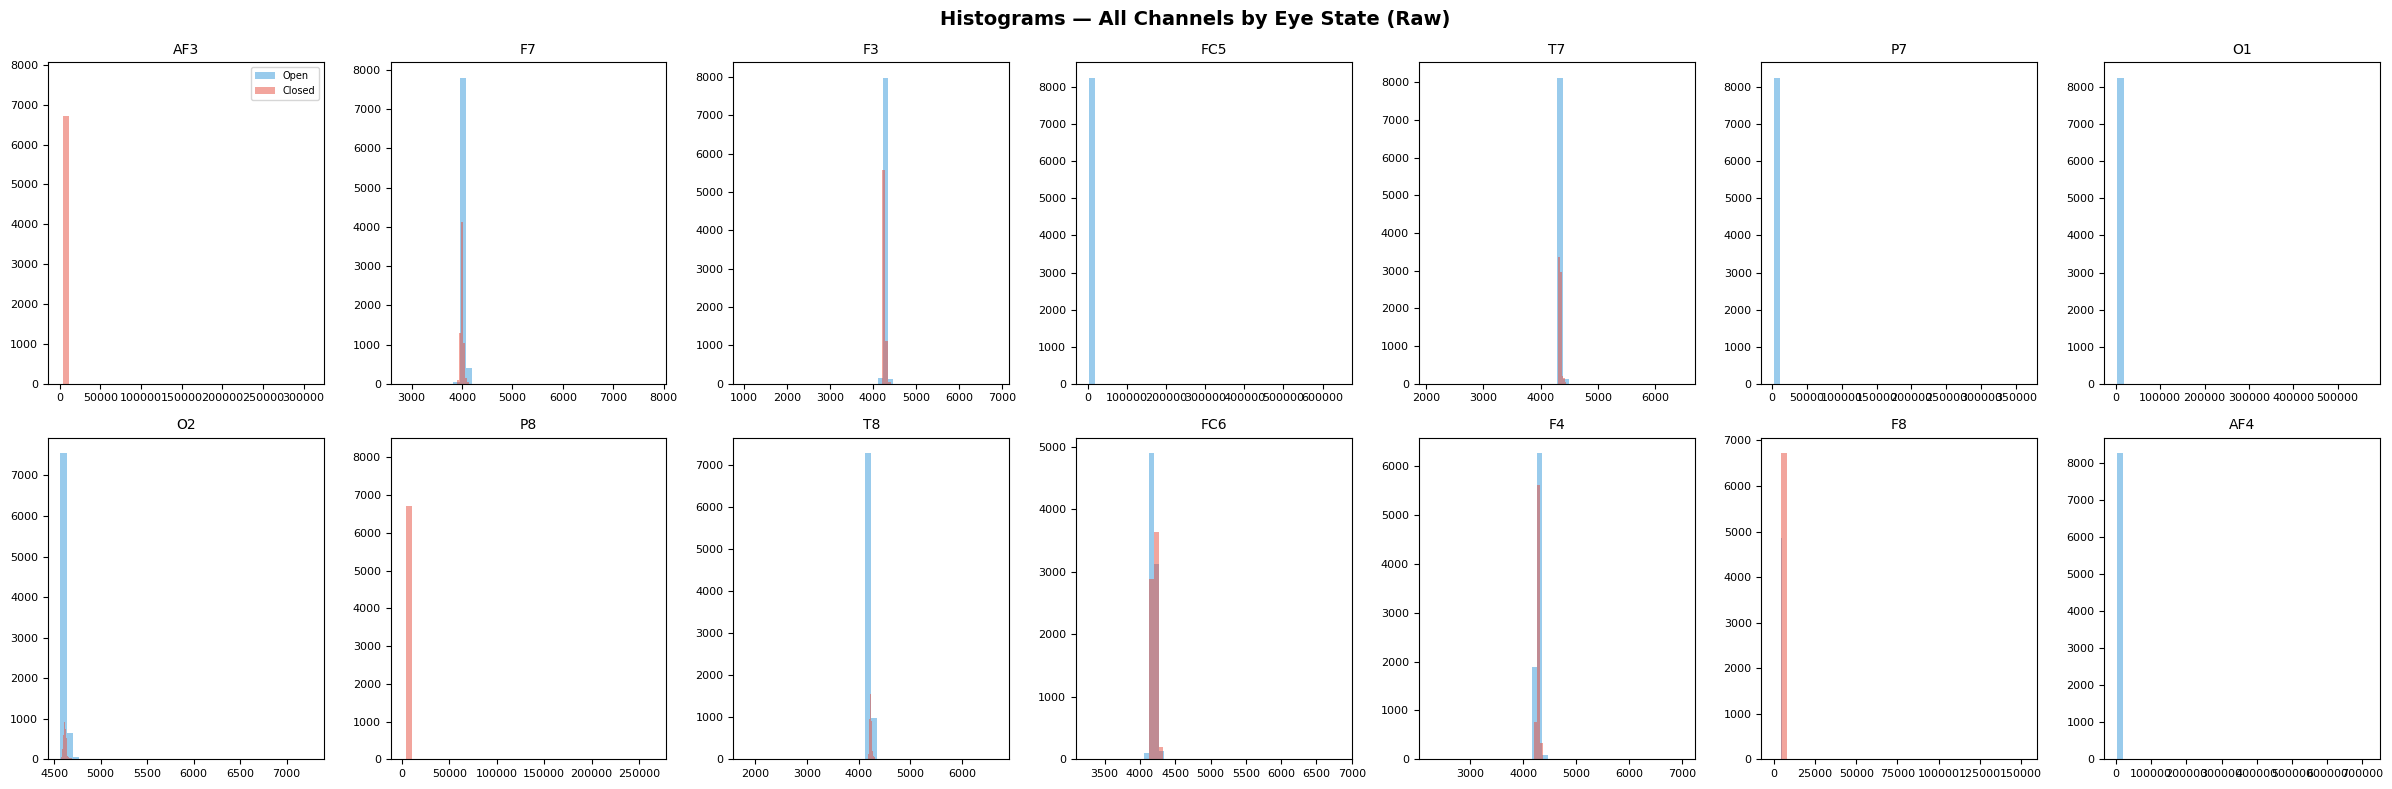

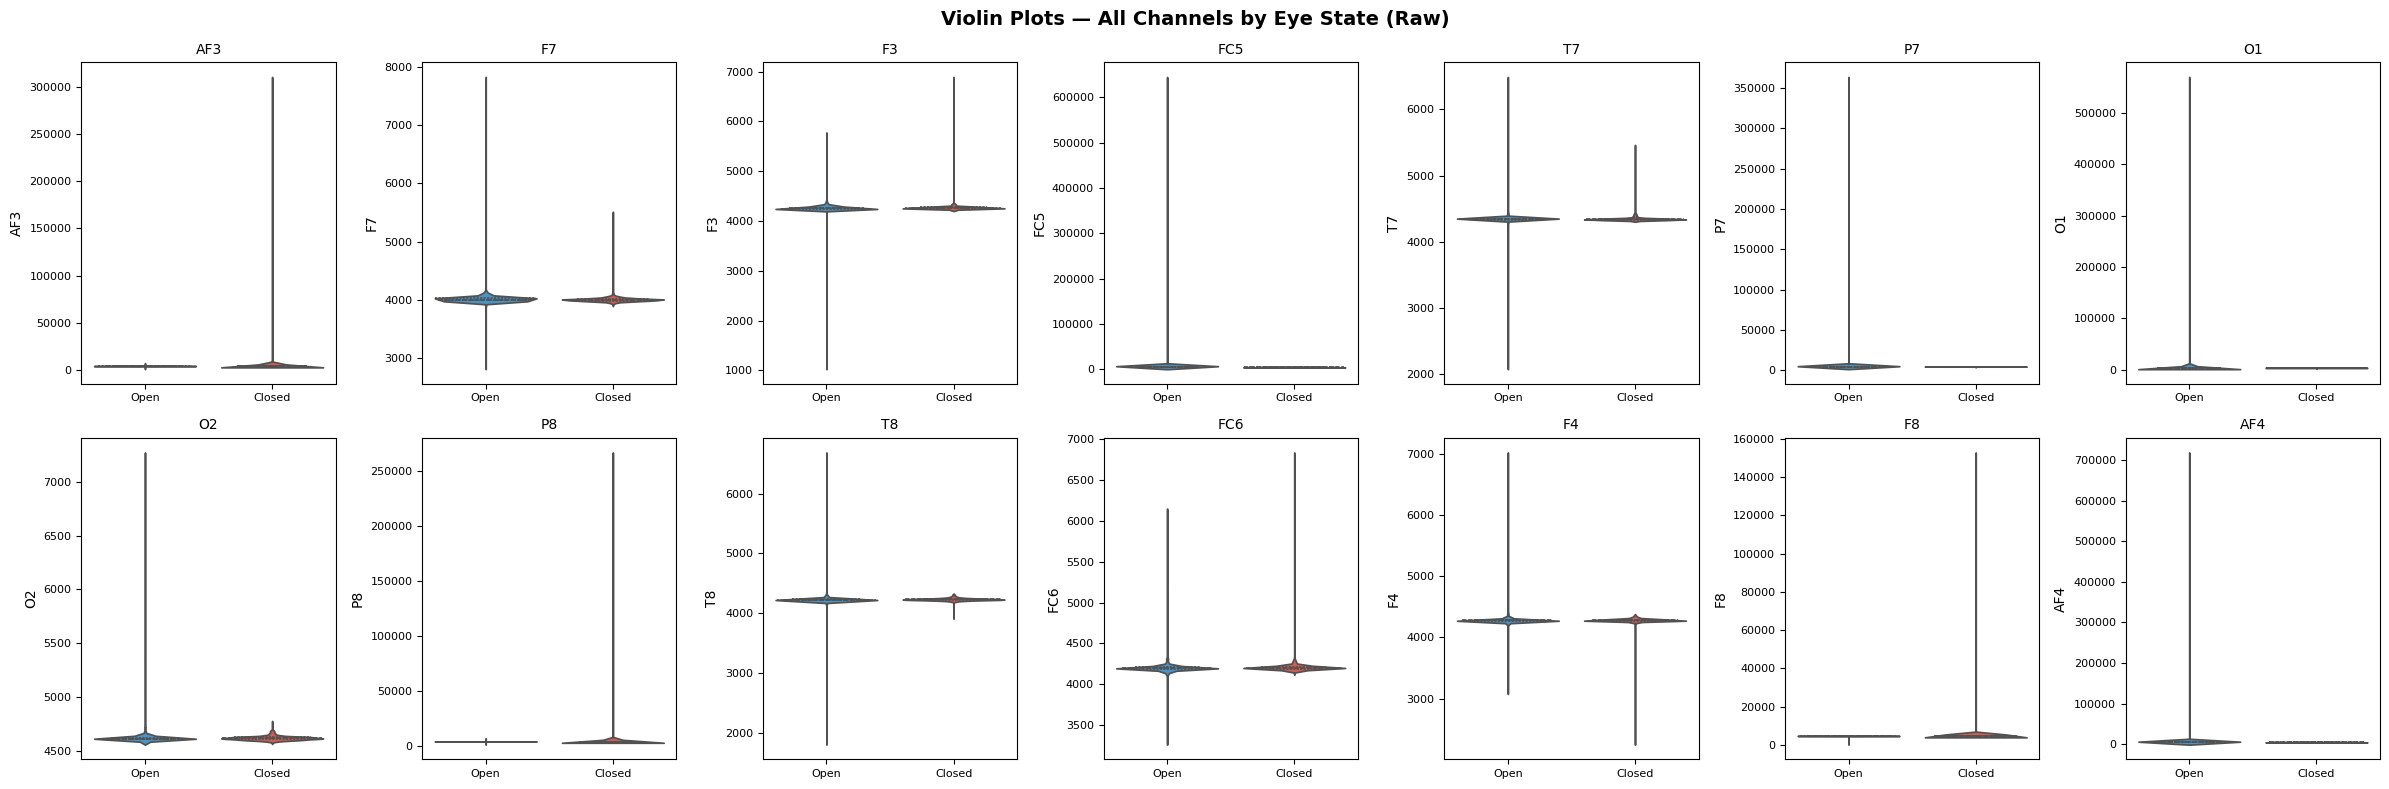

In [6]:
def section_data_viz_raw(df):
    # Class balance
    (fig, ax) = plt.subplots(figsize=(6, 4))
    vc = df[TARGET].value_counts()
    bars = ax.bar(['Open (0)', 'Closed (1)'],
                  [vc.get(0, 0), vc.get(1, 0)],
                  color=['#3498db', '#e74c3c'], edgecolor='black')
    ax.set_title('Class Balance of Eye States')
    ax.set_ylabel('Count')
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height()+30,
                str(int(b.get_height())), ha='center', fontweight='bold')
    save_fig('class_balance_raw.png')

    # Correlation heatmap (winsorized)
    df_win = df[FEATURE_COLUMNS].clip(
        lower=df[FEATURE_COLUMNS].quantile(0.01),
        upper=df[FEATURE_COLUMNS].quantile(0.99), axis=1)
    (fig, ax) = plt.subplots(figsize=(12, 10))
    sns.heatmap(df_win.corr(), annot=True, cmap='coolwarm', fmt='.2f',
                ax=ax, square=True, linewidths=0.5)
    ax.set_title('Correlation Heatmap (winsorized 1st–99th pct)')
    save_fig('correlation_heatmap_raw.png')

    # Box plots — raw
    (fig, axes) = plt.subplots(2, 7, figsize=(24, 8))
    for (i, ch) in enumerate(FEATURE_COLUMNS):
        ax = axes.flatten()[i]
        sns.boxplot(y=df[ch], ax=ax, color='#3498db')
        ax.set_title(ch, fontsize=10)
        ax.tick_params(labelsize=8)
    plt.suptitle('Box Plots — All EEG Channels (Raw)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_fig('boxplots_raw.png')

    # Box plots — zoomed
    (fig, axes) = plt.subplots(2, 7, figsize=(24, 8))
    for (i, ch) in enumerate(FEATURE_COLUMNS):
        ax = axes.flatten()[i]
        sns.boxplot(y=df[ch], ax=ax, color='#3498db')
        (lo, hi) = (df[ch].quantile(0.01), df[ch].quantile(0.99))
        ax.set_ylim(lo-(hi-lo)*0.1, hi+(hi-lo)*0.1)
        ax.set_title(ch, fontsize=10)
        ax.tick_params(labelsize=8)
    plt.suptitle('Box Plots — Zoomed (1st–99th percentile)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_fig('boxplots_raw_zoomed.png')

    # Histograms by eye state
    (fig, axes) = plt.subplots(2, 7, figsize=(24, 8))
    for (i, ch) in enumerate(FEATURE_COLUMNS):
        ax = axes.flatten()[i]
        for (state, color) in [(0, '#3498db'), (1, '#e74c3c')]:
            ax.hist(df.loc[df[TARGET]==state, ch], bins=40, alpha=0.5,
                    color=color, label=EYE_MAP[state])
        ax.set_title(ch, fontsize=10)
        ax.tick_params(labelsize=8)
        if i == 0: ax.legend(fontsize=7)
    plt.suptitle('Histograms — All Channels by Eye State (Raw)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_fig('histograms_raw.png')

    # Violin plots
    df_tmp = df.copy()
    df_tmp['eyeState'] = df_tmp[TARGET].map(EYE_MAP)
    (fig, axes) = plt.subplots(2, 7, figsize=(24, 8))
    for (i, ch) in enumerate(FEATURE_COLUMNS):
        ax = axes.flatten()[i]
        sns.violinplot(x='eyeState', y=ch, data=df_tmp, ax=ax,
                       palette=['#3498db','#e74c3c'], inner='quartile',
                       order=['Open','Closed'])
        ax.set_title(ch, fontsize=10)
        ax.set_xlabel('')
        ax.tick_params(labelsize=8)
    plt.suptitle('Violin Plots — All Channels by Eye State (Raw)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_fig('violinplots_raw.png')

# ── Run section ─────────────────────────────────────────────────────────
progress('[3/12] Visualising raw data ...')
section_data_viz_raw(df)


## Step 4 — Signal Preprocessing

Two-stage cleaning: (1) IQR-based outlier removal (3× IQR, up to 3 passes), then (2) 4th-order Butterworth bandpass filter (0.5–45 Hz).


[4/12] Signal preprocessing (bandpass + IQR) ...
IQR removed: 1374 rows (9.2%) in 3 pass(es)


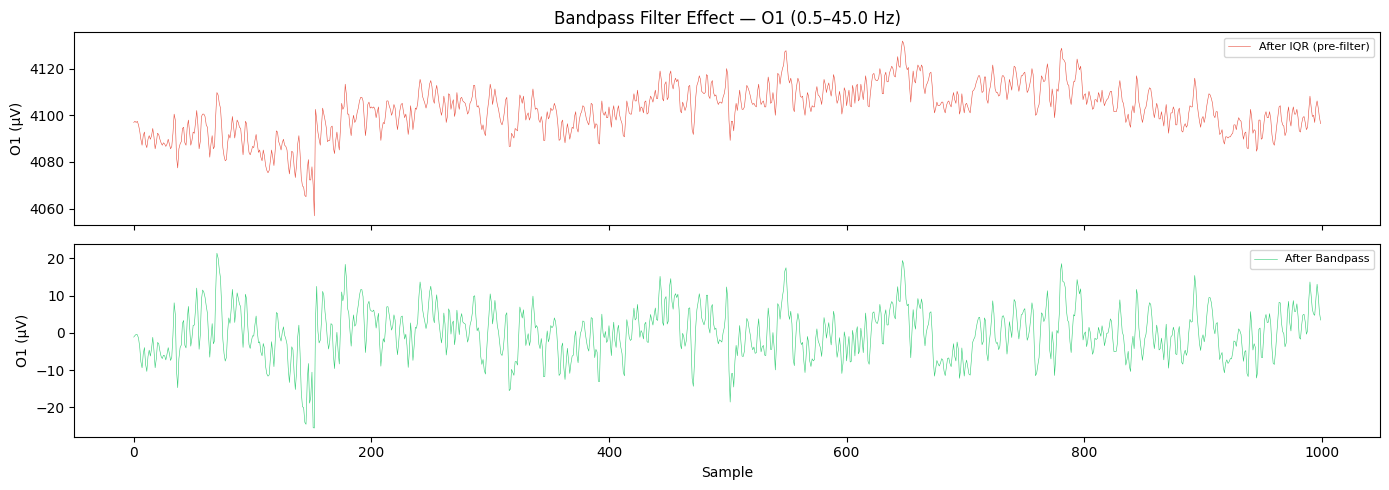

Total removed: 1374 (9.2%), remaining: 13606


In [7]:
def _bandpass_filter(df, lowcut=0.5, highcut=45.0, fs=None, order=4):
    """Apply Butterworth bandpass filter to all EEG channels."""
    if fs is None:
        fs = SAMPLING_RATE
    nyq = fs / 2.0
    (b, a) = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    filtered = df.copy()
    for col in FEATURE_COLUMNS:
        filtered[col] = filtfilt(b, a, df[col].values)
    return filtered


def _light_iqr(df, multiplier=3.0, max_passes=3):
    """Safety-net IQR outlier removal with wider bounds."""
    cleaned = df.copy()
    pass_num = 0
    bounds = []
    while True:
        pass_num += 1
        before = len(cleaned)
        for col in FEATURE_COLUMNS:
            (Q1, Q3) = (cleaned[col].quantile(0.25), cleaned[col].quantile(0.75))
            IQR = Q3 - Q1
            (lo, hi) = (Q1 - multiplier*IQR, Q3 + multiplier*IQR)
            cleaned = cleaned[(cleaned[col] >= lo) & (cleaned[col] <= hi)]
            if pass_num == 1:
                bounds.append([col, f'{lo:.2f}', f'{hi:.2f}'])
        after = len(cleaned)
        if before - after == 0 or pass_num >= max_passes:
            break
    return (cleaned.reset_index(drop=True), bounds, pass_num)


def section_preprocessing(df):
    original_count = len(df)
    cfg_pre = CONFIG.get('preprocessing', {})
    iqr_cfg  = cfg_pre.get('iqr', {})
    iqr_mult = iqr_cfg.get('multiplier', 3.0)
    iqr_pass = iqr_cfg.get('max_passes', 3)
    bp_cfg   = cfg_pre.get('bandpass', {})
    lowcut   = bp_cfg.get('lowcut',  0.5)
    highcut  = bp_cfg.get('highcut', 45.0)
    bp_order = bp_cfg.get('order', 4)

    (df_iqr, bounds, n_passes) = _light_iqr(df, multiplier=iqr_mult, max_passes=iqr_pass)
    removed_iqr = original_count - len(df_iqr)
    print(f'IQR removed: {removed_iqr} rows ({removed_iqr/original_count*100:.1f}%) in {n_passes} pass(es)')

    df_clean = _bandpass_filter(df_iqr, lowcut=lowcut, highcut=highcut,
                                fs=SAMPLING_RATE, order=bp_order)

    # Visualise bandpass effect on sample channel
    sample_ch = 'O1'
    n_show = min(1000, len(df_iqr))
    (fig, axes) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
    axes[0].plot(range(n_show), df_iqr[sample_ch].iloc[:n_show].values,
                 linewidth=0.4, color='#e74c3c', label='After IQR (pre-filter)')
    axes[1].plot(range(n_show), df_clean[sample_ch].iloc[:n_show].values,
                 linewidth=0.4, color='#2ecc71', label='After Bandpass')
    for ax in axes:
        ax.legend(fontsize=8, loc='upper right')
        ax.set_ylabel(f'{sample_ch} (µV)')
    axes[1].set_xlabel('Sample')
    axes[0].set_title(f'Bandpass Filter Effect — {sample_ch} ({lowcut}–{highcut} Hz)')
    plt.tight_layout()
    save_fig('bandpass_filter_comparison.png')

    total_removed = original_count - len(df_clean)
    print(f'Total removed: {total_removed} ({total_removed/original_count*100:.1f}%), '
          f'remaining: {len(df_clean)}')
    return df_clean

# ── Run section ─────────────────────────────────────────────────────────
progress('[4/12] Signal preprocessing (bandpass + IQR) ...')
df_raw_copy = df.copy()
df_clean = section_preprocessing(df)


## Step 5 — Cleaned Data Visualisation

Correlation heatmap, box plots, and histograms after IQR + bandpass preprocessing.


[5/12] Visualising cleaned data ...


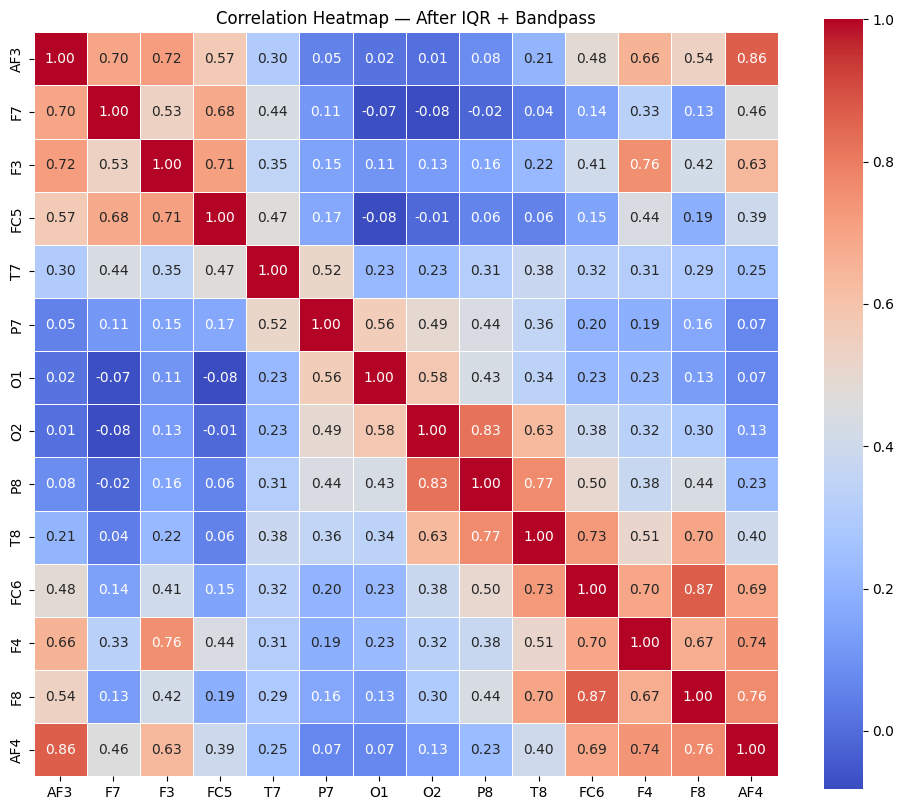

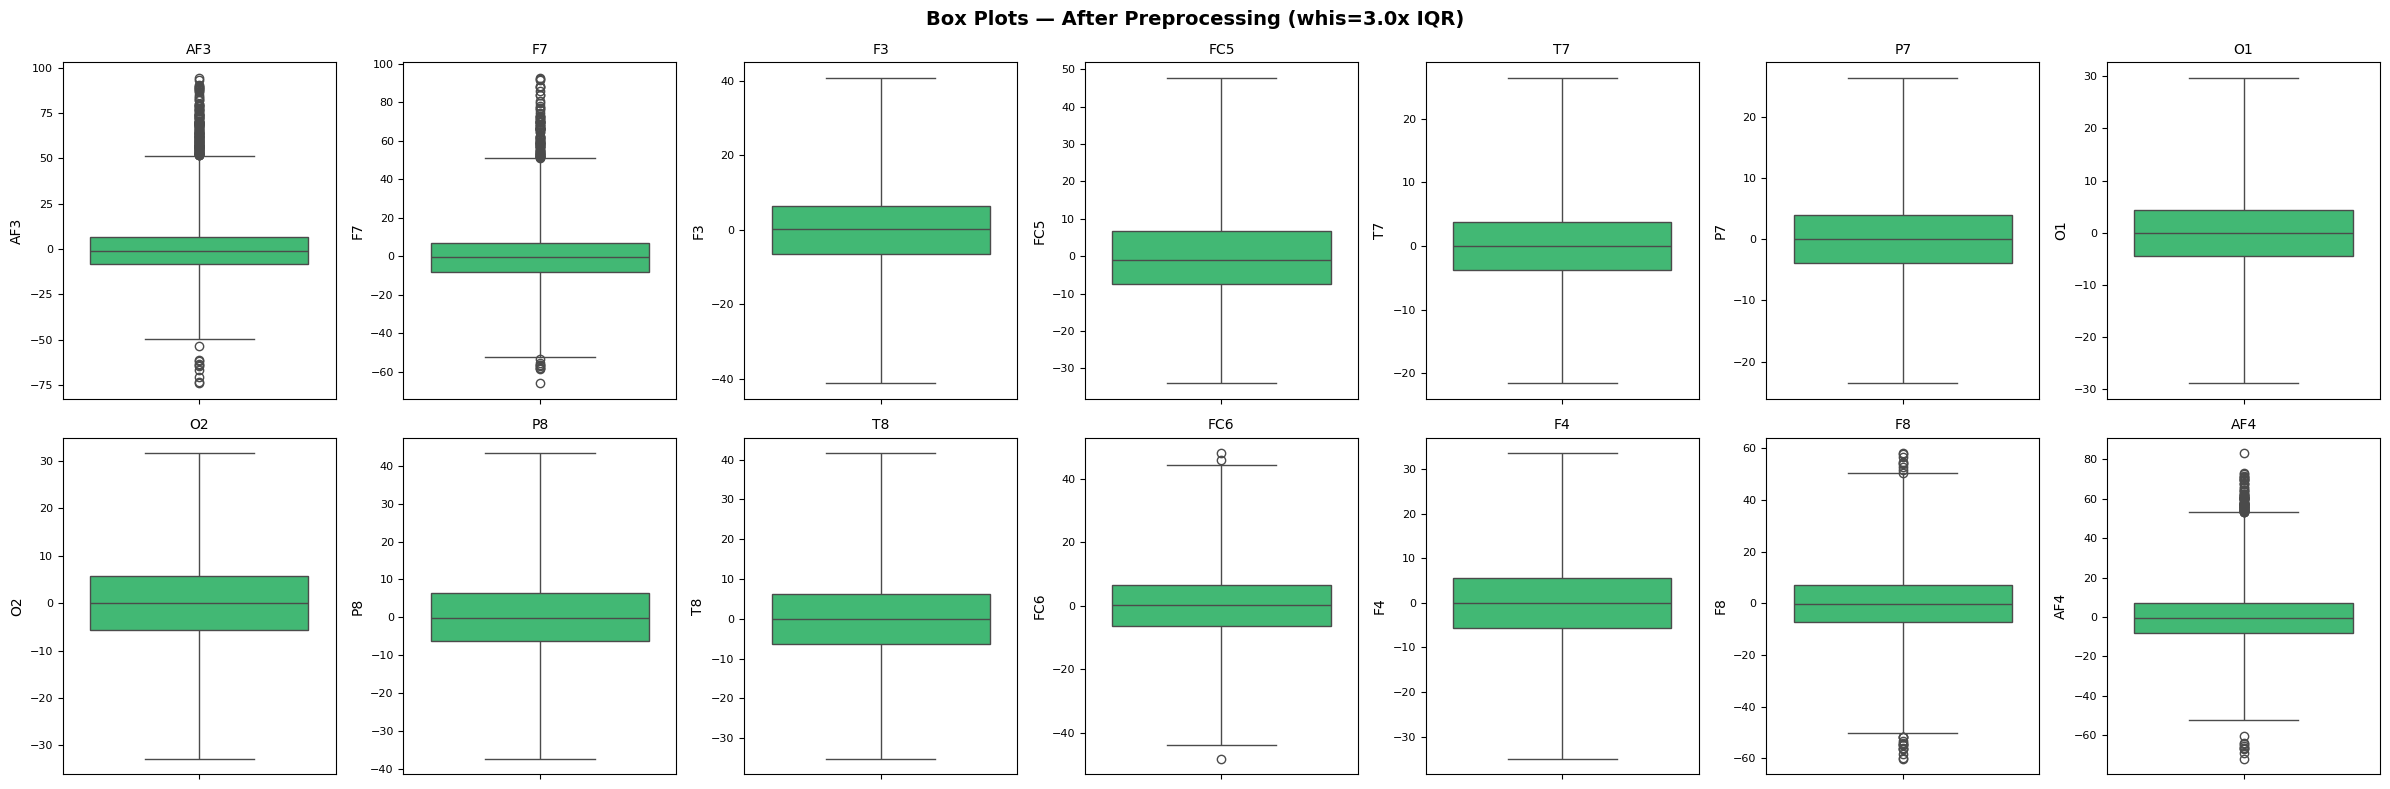

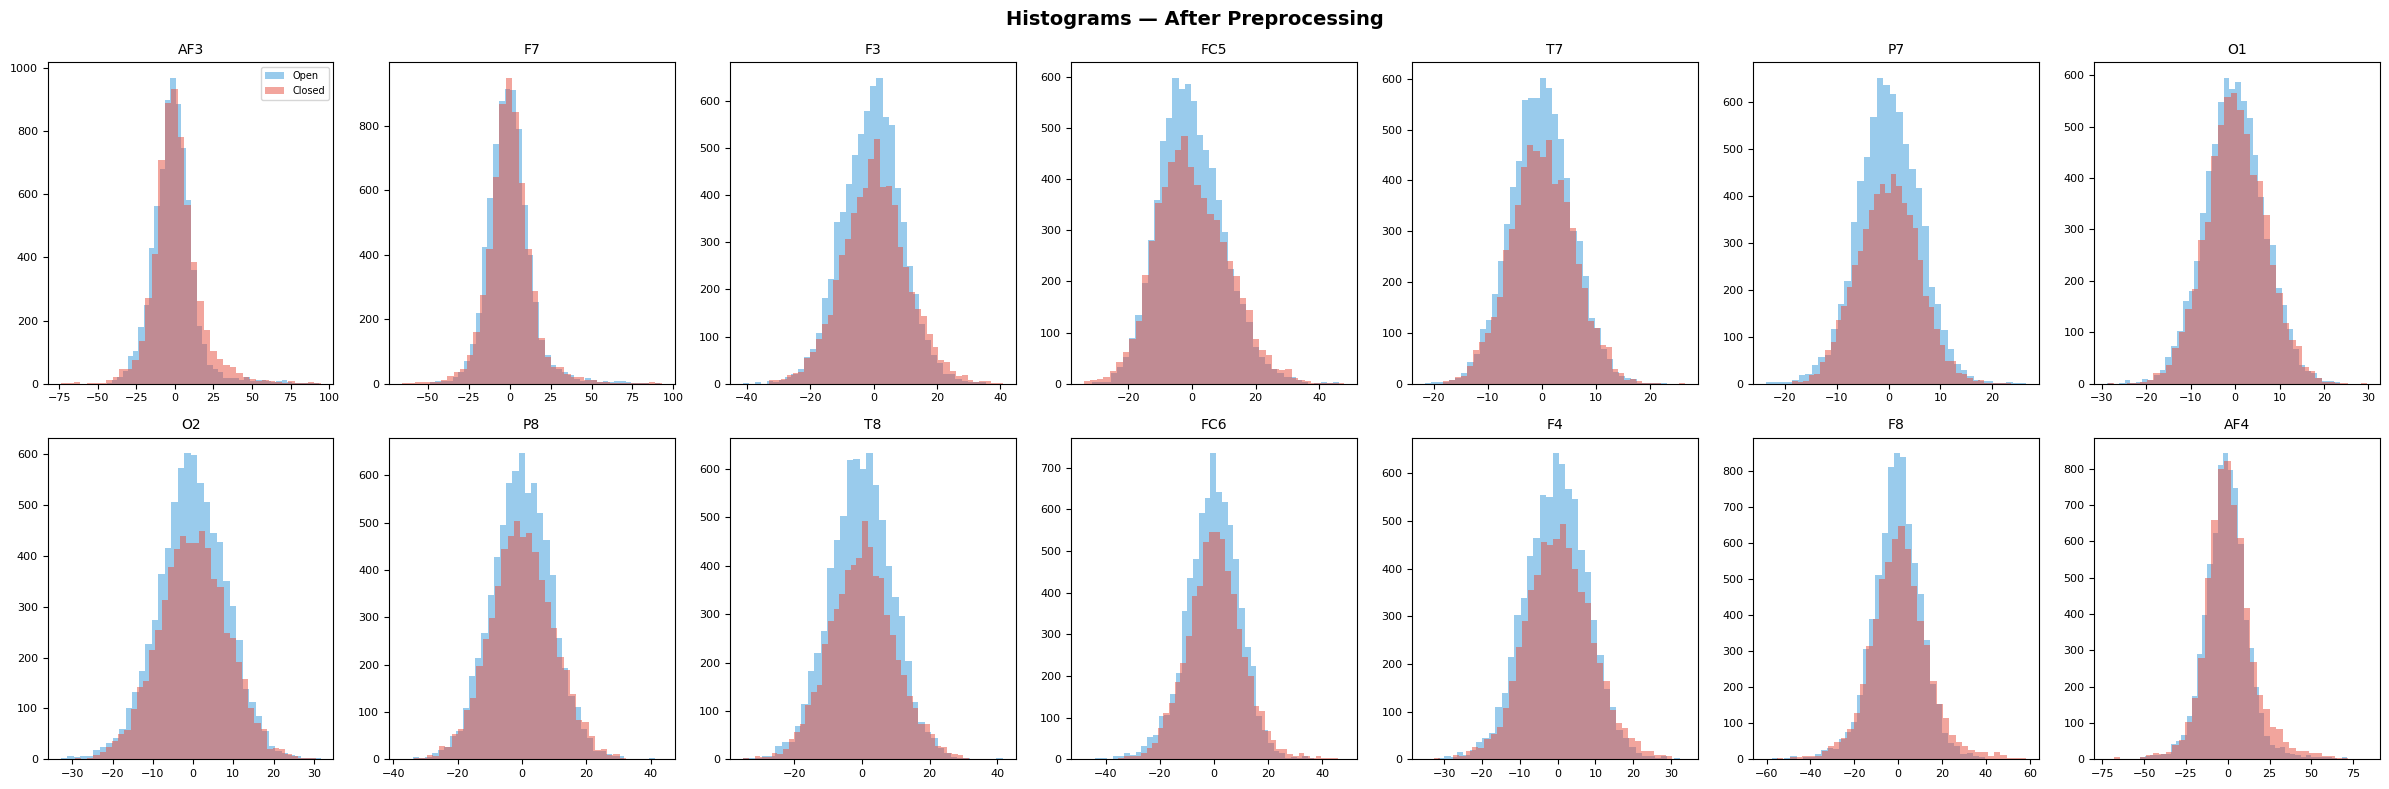

In [8]:
def section_data_viz_cleaned(df_raw, df_clean):
    # Correlation heatmap — cleaned
    (fig, ax) = plt.subplots(figsize=(12, 10))
    sns.heatmap(df_clean[FEATURE_COLUMNS].corr(), annot=True, cmap='coolwarm',
                fmt='.2f', ax=ax, square=True, linewidths=0.5)
    ax.set_title('Correlation Heatmap — After IQR + Bandpass')
    save_fig('correlation_heatmap_cleaned.png')

    # Box plots — cleaned
    (fig, axes) = plt.subplots(2, 7, figsize=(24, 8))
    for (i, ch) in enumerate(FEATURE_COLUMNS):
        ax = axes.flatten()[i]
        sns.boxplot(y=df_clean[ch], ax=ax, color='#2ecc71', whis=3.0)
        ax.set_title(ch, fontsize=10)
        ax.tick_params(labelsize=8)
    plt.suptitle('Box Plots — After Preprocessing (whis=3.0x IQR)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_fig('boxplots_cleaned.png')

    # Histograms — cleaned
    (fig, axes) = plt.subplots(2, 7, figsize=(24, 8))
    for (i, ch) in enumerate(FEATURE_COLUMNS):
        ax = axes.flatten()[i]
        for (state, color) in [(0, '#3498db'), (1, '#e74c3c')]:
            ax.hist(df_clean.loc[df_clean[TARGET]==state, ch], bins=40,
                    alpha=0.5, color=color, label=EYE_MAP[state])
        ax.set_title(ch, fontsize=10)
        ax.tick_params(labelsize=8)
        if i == 0: ax.legend(fontsize=7)
    plt.suptitle('Histograms — After Preprocessing', fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_fig('histograms_cleaned.png')

# ── Run section ─────────────────────────────────────────────────────────
progress('[5/12] Visualising cleaned data ...')
section_data_viz_cleaned(df_raw_copy, df_clean)


## Step 6 — Log Normalisation Assessment

Evaluate whether `log10(x − min + 1)` improves skewness and kurtosis for each channel.


[6/12] Log-normalisation assessment ...


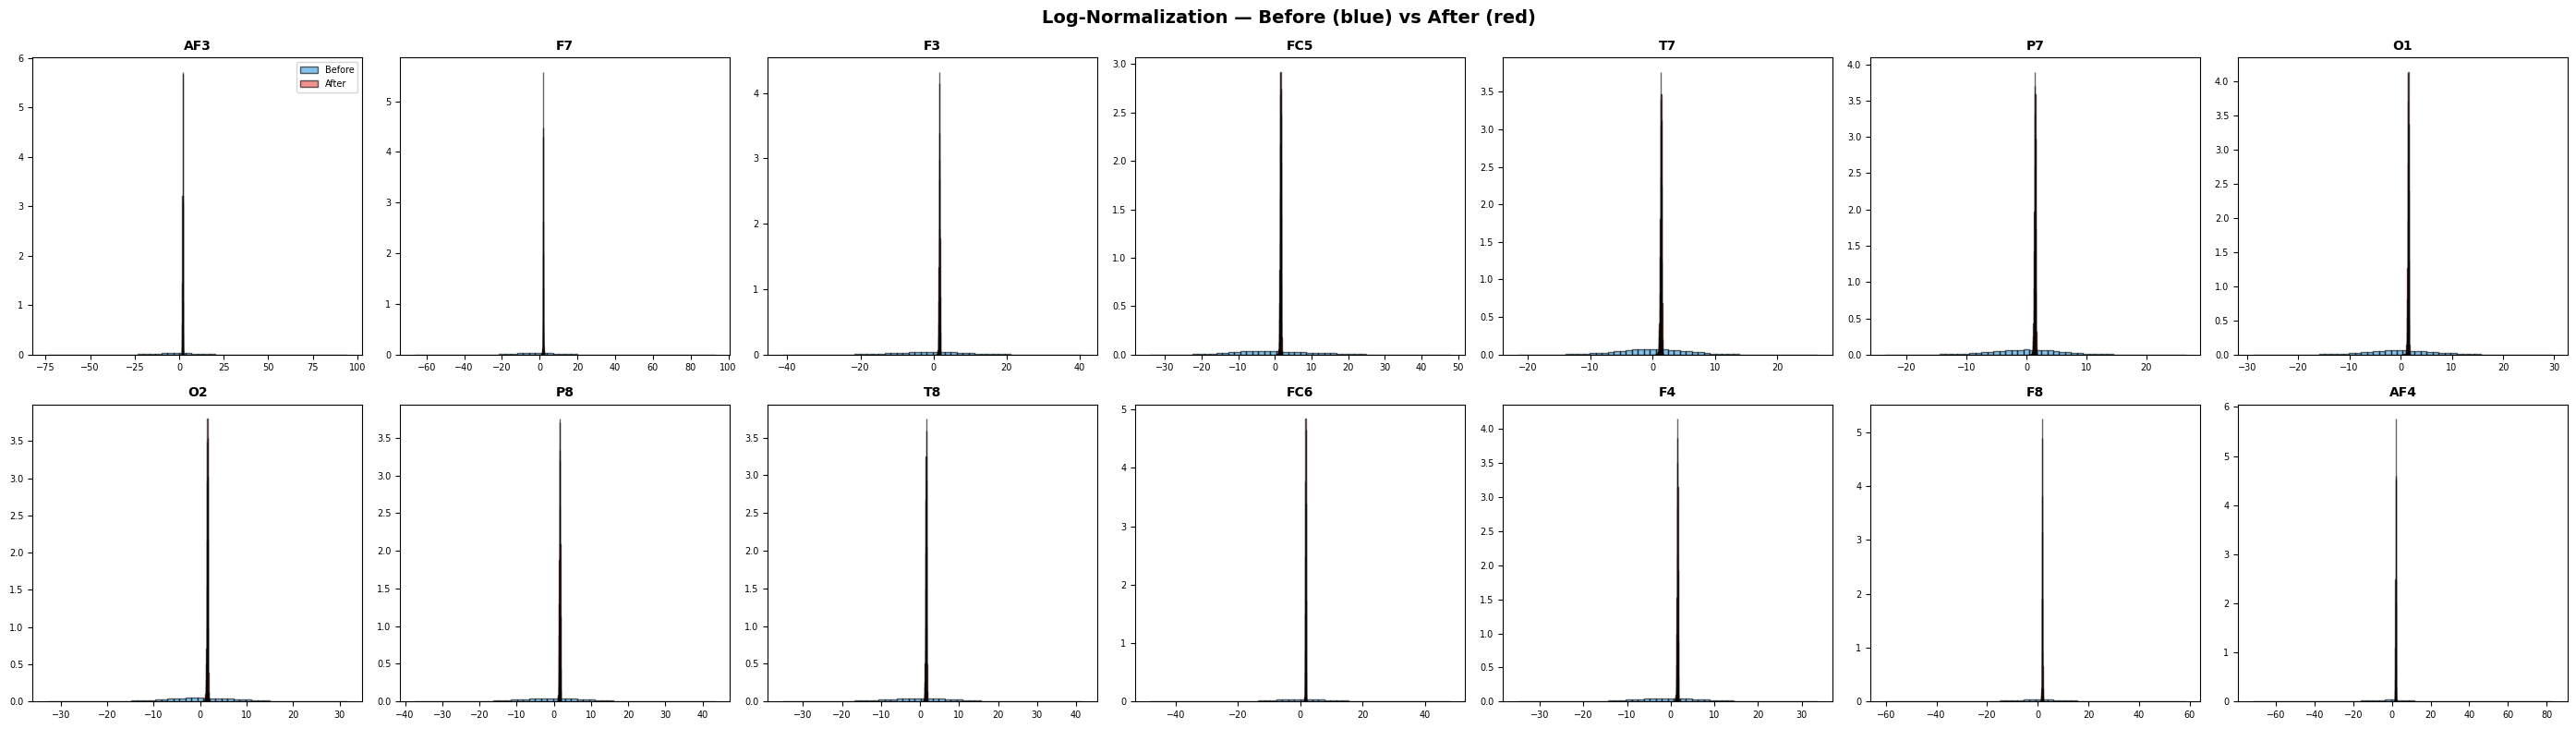

Channels improved by log-norm: 0/14 (0%)


,Channel,Skew Before,Skew After,Kurt Before,Kurt After,Improved
0,AF3,1.1249,-1.7574,4.9780,30.0971,No
1,F7,0.8910,-1.4597,4.3920,17.7217,No
2,F3,0.0441,-1.2756,0.3341,6.6803,No
3,FC5,0.3711,-1.0258,0.2470,4.1555,No
4,T7,0.0352,-1.1706,0.0545,4.4658,No
5,P7,0.0262,-1.2269,0.2009,5.4426,No
6,O1,-0.0039,-1.4086,0.1945,8.5652,No
7,O2,-0.0519,-1.5131,0.1288,7.3115,No
8,P8,0.0219,-1.2489,0.1634,5.2143,No
9,T8,0.0111,-1.5541,0.1634,8.0981,No


In [9]:
def section_log_normalization(df):
    df_norm = df.copy()
    for col in FEATURE_COLUMNS:
        df_norm[col] = np.log10(df[col] - df[col].min() + 1)

    (fig, axes) = plt.subplots(2, 7, figsize=(28, 8))
    for (idx, ch) in enumerate(FEATURE_COLUMNS):
        (row, col) = divmod(idx, 7)
        ax = axes[row, col]
        ax.hist(df[ch], bins=50, color='#3498db', alpha=0.6,
                edgecolor='black', label='Before', density=True)
        ax.hist(df_norm[ch], bins=50, color='#e74c3c', alpha=0.6,
                edgecolor='black', label='After',  density=True)
        ax.set_title(ch, fontsize=10, fontweight='bold')
        ax.tick_params(labelsize=7)
        if idx == 0: ax.legend(fontsize=7)
    plt.suptitle('Log-Normalization — Before (blue) vs After (red)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_fig('log_normalization_all_channels.png')

    sk_rows = []
    improved_count = 0
    for ch in FEATURE_COLUMNS:
        sk_b = skew(df[ch].values)
        sk_a = skew(df_norm[ch].values)
        kt_b = kurtosis(df[ch].values)
        kt_a = kurtosis(df_norm[ch].values)
        improved = abs(sk_a)+abs(kt_a) < abs(sk_b)+abs(kt_b)
        if improved: improved_count += 1
        sk_rows.append([ch, f'{sk_b:.4f}', f'{sk_a:.4f}',
                         f'{kt_b:.4f}', f'{kt_a:.4f}', 'Yes' if improved else 'No'])
    print(f'Channels improved by log-norm: {improved_count}/{len(FEATURE_COLUMNS)} '
          f'({improved_count/len(FEATURE_COLUMNS)*100:.0f}%)')
    return pd.DataFrame(sk_rows, columns=['Channel','Skew Before','Skew After',
                                           'Kurt Before','Kurt After','Improved'])

# ── Run section ─────────────────────────────────────────────────────────
progress('[6/12] Log-normalisation assessment ...')
lognorm_df = section_log_normalization(df_clean)
display(lognorm_df)


## Step 7 — Feature Engineering

Derived features: hemispheric asymmetry pairs, per-band average power (Delta / Theta / Alpha / Beta / Gamma), alpha asymmetry (O1 vs O2), and global channel mean / std.


[7/12] Feature engineering ...
Significant asymmetry features (p<0.05): 2/7


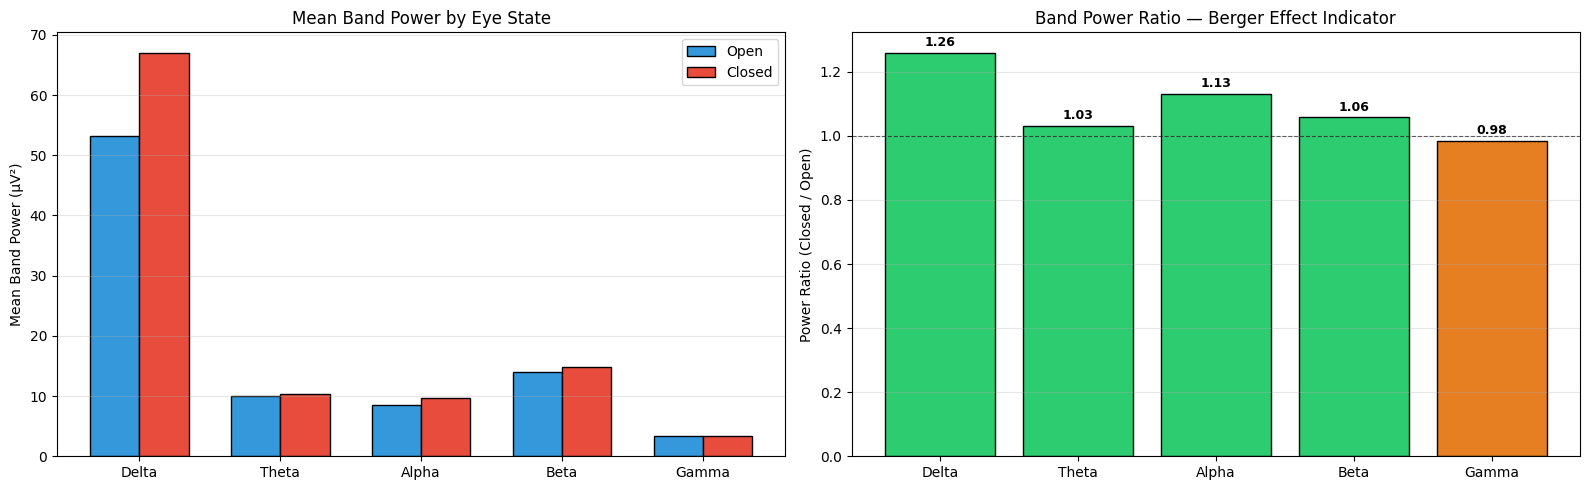

Total features after engineering: 29


In [10]:
def section_feature_engineering(df):
    df_eng = df.copy()
    new_features = []

    # Hemispheric asymmetry
    asym_rows = []
    for (left, right) in HEMI_PAIRS:
        fname = f'{left}_{right}_asym'
        df_eng[fname] = df_eng[left] - df_eng[right]
        new_features.append(fname)
        asym_rows.append([fname, left, right,
                          f'{df_eng[fname].mean():.4f}', f'{df_eng[fname].std():.4f}'])

    asym_state_rows = []
    for (left, right) in HEMI_PAIRS:
        fname = f'{left}_{right}_asym'
        open_vals   = df_eng.loc[df_eng[TARGET]==0, fname].values
        closed_vals = df_eng.loc[df_eng[TARGET]==1, fname].values
        (t_stat, p_val) = ttest_ind(open_vals, closed_vals, equal_var=False)
        sig = 'Yes' if p_val < 0.05 else 'No'
        asym_state_rows.append([fname, f'{open_vals.mean():.4f}',
                                 f'{closed_vals.mean():.4f}',
                                 f'{t_stat:.3f}', f'{p_val:.2e}', sig])
    sig_count = sum(1 for r in asym_state_rows if r[5]=='Yes')
    print(f'Significant asymmetry features (p<0.05): {sig_count}/{len(HEMI_PAIRS)}')

    # Band-power features
    nyq = SAMPLING_RATE / 2.0
    band_rows = []
    for (band_name, (fmin, fmax)) in FREQ_BANDS.items():
        (b_bp, a_bp) = butter(4, [max(fmin/nyq, 0.001), min(fmax/nyq, 0.999)], btype='band')
        feat_name = f'band_{band_name}_power'
        df_eng[feat_name] = np.mean(
            [filtfilt(b_bp, a_bp, df[ch].values)**2 for ch in FEATURE_COLUMNS], axis=0)
        new_features.append(feat_name)
        band_rows.append([feat_name, f'{fmin}–{fmax} Hz',
                          f'{df_eng[feat_name].mean():.4f}',
                          f'{df_eng[feat_name].std():.4f}'])

    # Alpha asymmetry O1 vs O2
    (b_al, a_al) = butter(4, [8/nyq, 12/nyq], btype='band')
    df_eng['alpha_asymmetry'] = (filtfilt(b_al, a_al, df['O1'].values)**2
                                  - filtfilt(b_al, a_al, df['O2'].values)**2)
    new_features.append('alpha_asymmetry')

    # Band power bar chart
    band_names     = list(FREQ_BANDS.keys())
    band_feat_names = [f'band_{b}_power' for b in band_names]
    open_means   = [df_eng.loc[df_eng[TARGET]==0, f].mean() for f in band_feat_names]
    closed_means = [df_eng.loc[df_eng[TARGET]==1, f].mean() for f in band_feat_names]
    (fig, axes) = plt.subplots(1, 2, figsize=(16, 5))
    x = np.arange(len(band_names)); w = 0.35
    axes[0].bar(x-w/2, open_means,   w, label='Open',   color='#3498db', edgecolor='black')
    axes[0].bar(x+w/2, closed_means, w, label='Closed', color='#e74c3c', edgecolor='black')
    axes[0].set_xticks(x); axes[0].set_xticklabels(band_names)
    axes[0].set_ylabel('Mean Band Power (µV²)')
    axes[0].set_title('Mean Band Power by Eye State')
    axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')
    ratios = [c/o if o>0 else 0 for (o,c) in zip(open_means, closed_means)]
    colors = ['#2ecc71' if r>1.0 else '#e67e22' for r in ratios]
    axes[1].bar(band_names, ratios, color=colors, edgecolor='black')
    axes[1].axhline(y=1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
    axes[1].set_ylabel('Power Ratio (Closed / Open)')
    axes[1].set_title('Band Power Ratio — Berger Effect Indicator')
    axes[1].grid(True, alpha=0.3, axis='y')
    for (i, r) in enumerate(ratios):
        axes[1].text(i, r+0.02, f'{r:.2f}', ha='center', fontsize=9, fontweight='bold')
    plt.tight_layout()
    save_fig('band_power_eda.png')

    # Global stats
    df_eng['ch_mean'] = df_eng[FEATURE_COLUMNS].mean(axis=1)
    df_eng['ch_std']  = df_eng[FEATURE_COLUMNS].std(axis=1)
    new_features += ['ch_mean', 'ch_std']
    all_features = FEATURE_COLUMNS + new_features
    print(f'Total features after engineering: {len(all_features)}')
    return (df_eng, all_features)

# ── Run section ─────────────────────────────────────────────────────────
progress('[7/12] Feature engineering ...')
(df_eng, all_features) = section_feature_engineering(df_clean)


## Step 8 — Frequency-Domain Analysis

FFT spectrum, Welch PSD (open vs closed), and spectrograms for all 14 channels.


[8/12] Frequency-domain analysis ...


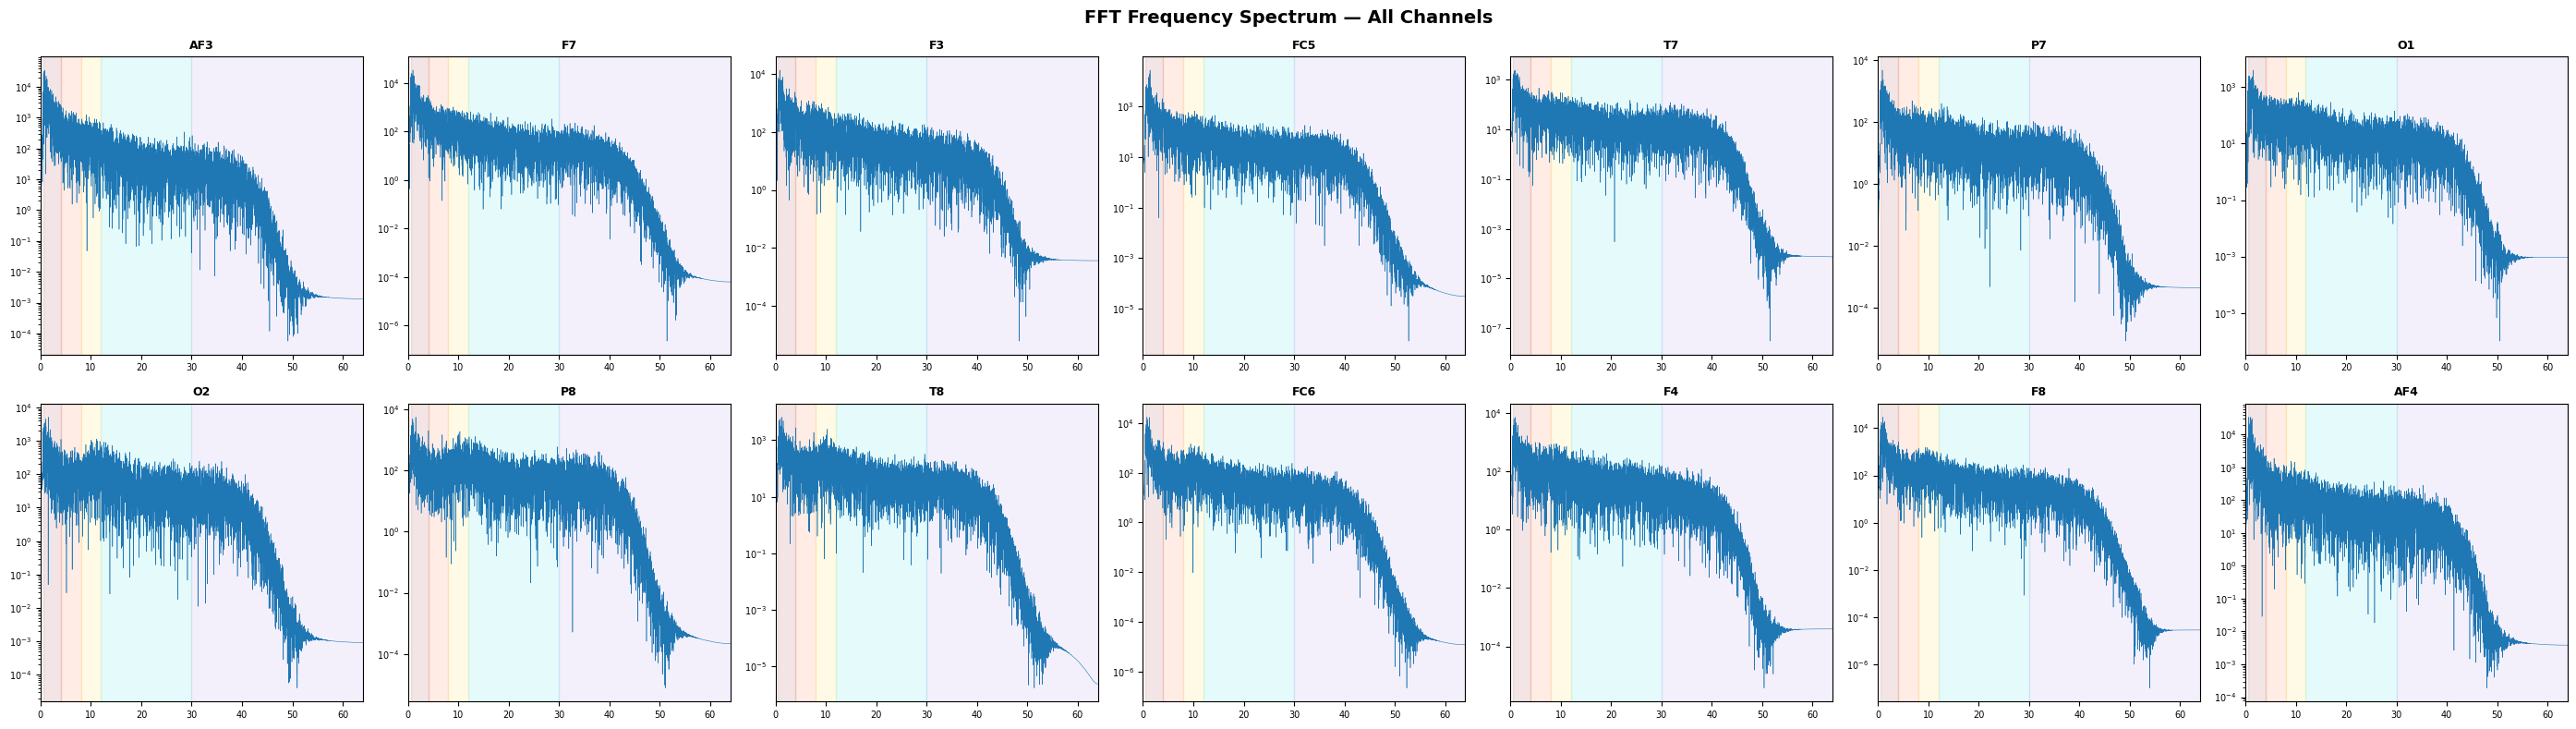

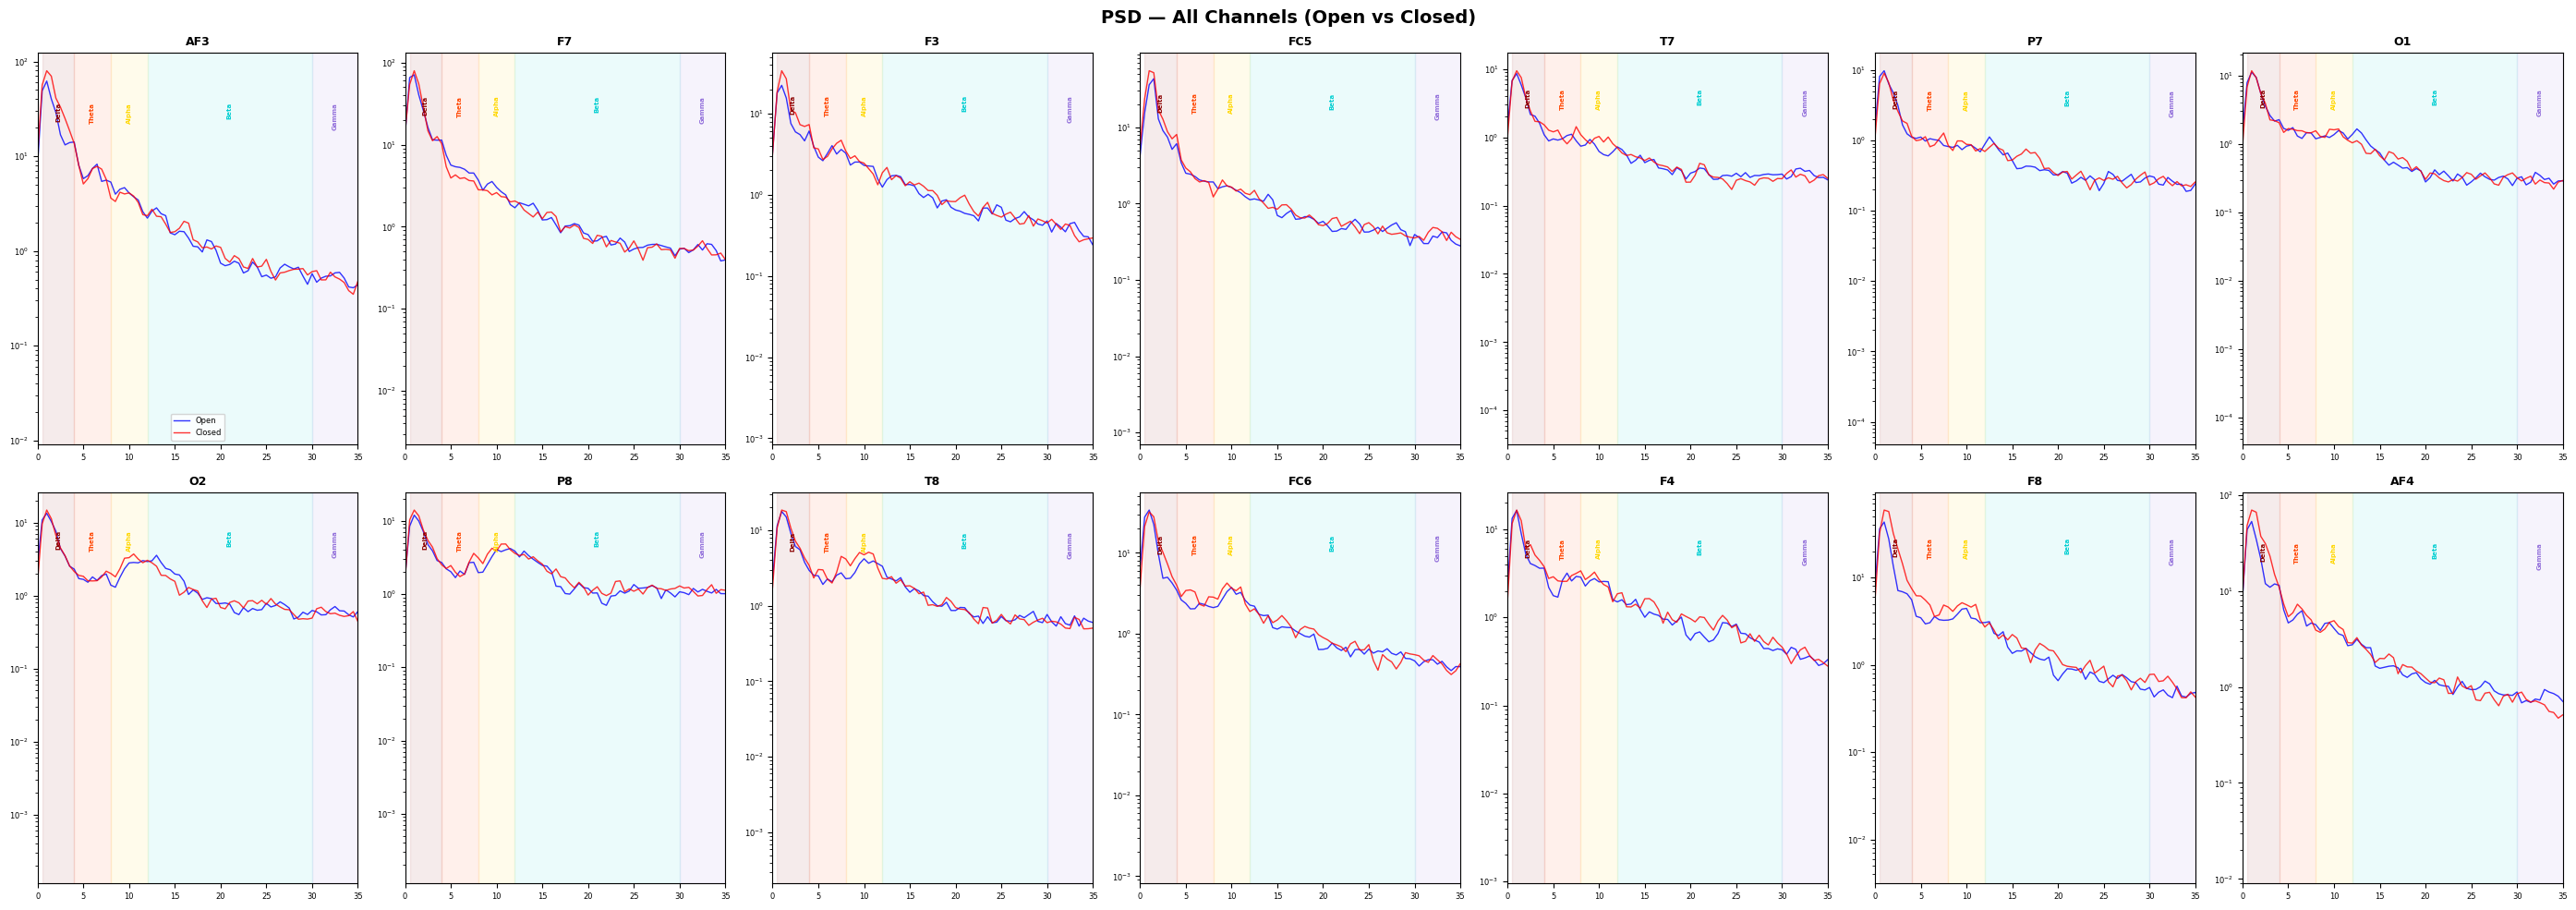

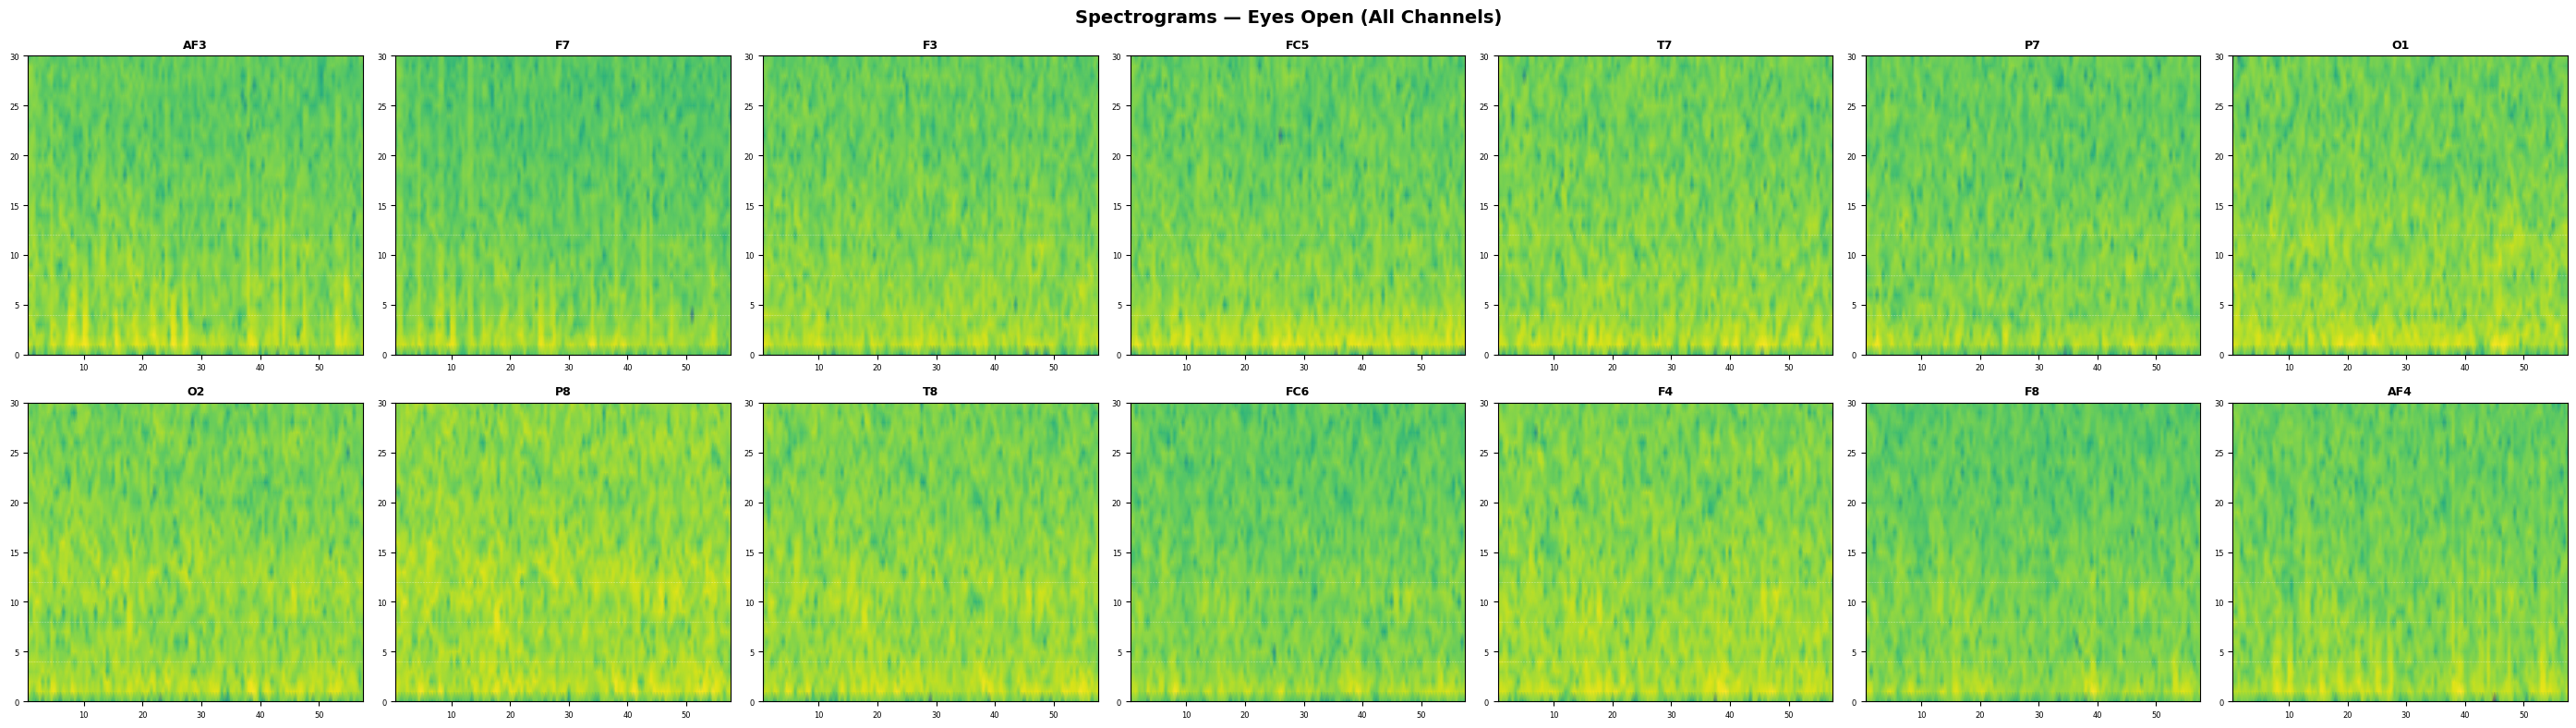

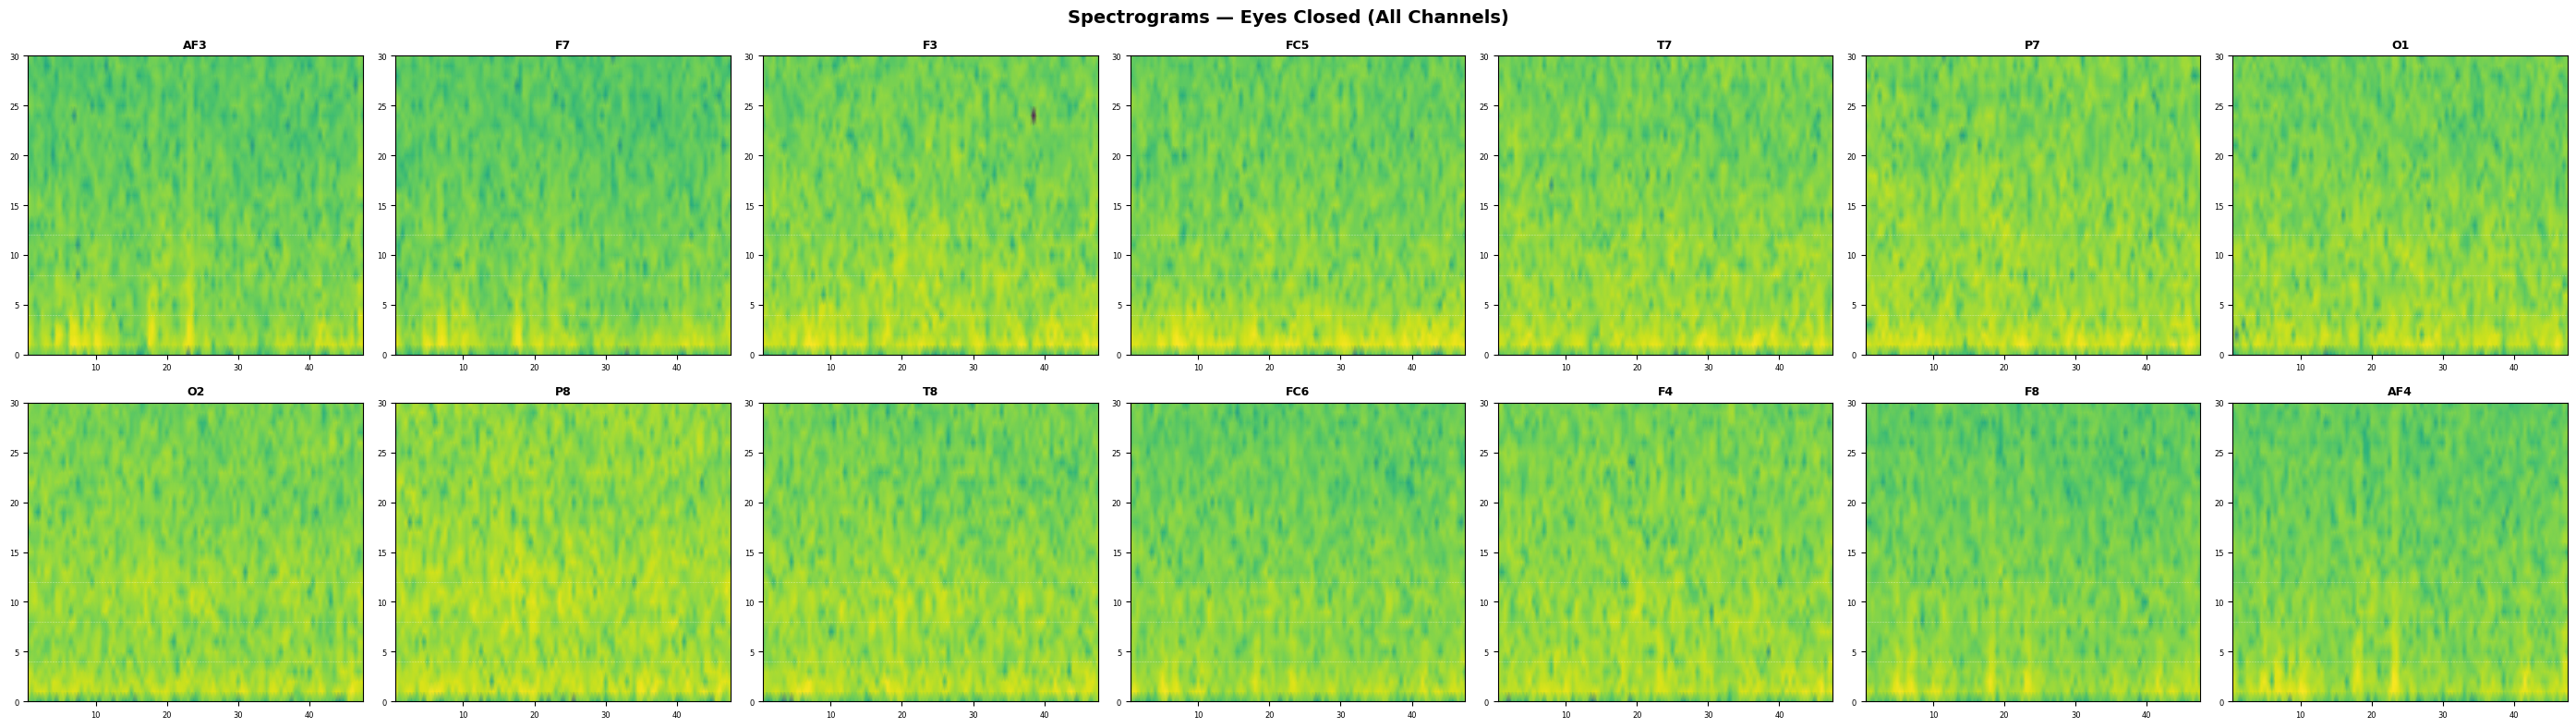

In [11]:
def section_fft_psd_spectro(df):
    # FFT spectrum
    (fig, axes) = plt.subplots(2, 7, figsize=(28, 8))
    for (idx, ch) in enumerate(FEATURE_COLUMNS):
        ax = axes.flatten()[idx]
        signal = df[ch].values
        n = len(signal)
        fft_vals = fft(signal)
        freqs    = fftfreq(n, 1/SAMPLING_RATE)
        pos      = freqs > 0
        power    = np.abs(fft_vals[pos])**2 / n
        ax.semilogy(freqs[pos], power, linewidth=0.4, color='#1f77b4')
        ax.set_xlim(0, 64)
        ax.set_title(ch, fontsize=9, fontweight='bold')
        ax.tick_params(labelsize=7)
        for (i, (_, (lo, hi))) in enumerate(FREQ_BANDS.items()):
            ax.axvspan(lo, hi, alpha=0.1, color=BAND_COLORS[i])
    plt.suptitle('FFT Frequency Spectrum — All Channels', fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_fig('fft_frequency_spectrum.png')

    # Welch PSD — open vs closed
    df_open   = df[df[TARGET]==0]
    df_closed = df[df[TARGET]==1]
    nperseg = min(256, len(df_open), len(df_closed))
    (fig, axes) = plt.subplots(2, 7, figsize=(28, 10))
    for (idx, ch) in enumerate(FEATURE_COLUMNS):
        ax = axes.flatten()[idx]
        (fo, po) = welch(df_open[ch].values,   SAMPLING_RATE, nperseg=nperseg)
        (fc, pc) = welch(df_closed[ch].values, SAMPLING_RATE, nperseg=nperseg)
        ax.semilogy(fo, po, label='Open',   color='blue', linewidth=1, alpha=0.8)
        ax.semilogy(fc, pc, label='Closed', color='red',  linewidth=1, alpha=0.8)
        ax.set_xlim(0, 35)
        ax.set_title(ch, fontsize=9, fontweight='bold')
        ax.tick_params(labelsize=6)
        ylims = ax.get_ylim()
        for (i, (bname, (lo, hi))) in enumerate(FREQ_BANDS.items()):
            bhi = min(hi, 35)
            ax.axvspan(lo, bhi, alpha=0.08, color=BAND_COLORS[i])
            if bhi <= 35:
                ax.text((lo+bhi)/2, ylims[1]*0.3, bname, fontsize=5,
                        ha='center', va='top', color=BAND_COLORS[i],
                        fontweight='bold', rotation=90)
        if idx == 0: ax.legend(fontsize=6)
    plt.suptitle('PSD — All Channels (Open vs Closed)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_fig('psd_analysis.png')

    # Spectrograms
    for (state_name, state_val) in [('Open', 0), ('Closed', 1)]:
        (fig, axes) = plt.subplots(2, 7, figsize=(28, 8))
        data_state = df[df[TARGET]==state_val]
        for (idx, ch) in enumerate(FEATURE_COLUMNS):
            ax = axes.flatten()[idx]
            data = data_state[ch].values
            seg  = max(4, min(128, len(data)//4))
            (f, t, Sxx) = scipy_spectrogram(data, fs=SAMPLING_RATE,
                                             nperseg=seg, noverlap=seg//2)
            ax.pcolormesh(t, f, 10*np.log10(Sxx+1e-10),
                          shading='gouraud', cmap='viridis')
            ax.set_ylim(0, 30)
            ax.set_title(ch, fontsize=9, fontweight='bold')
            ax.tick_params(labelsize=6)
            for freq in [4, 8, 12, 30]:
                ax.axhline(y=freq, color='white', linestyle='--',
                           linewidth=0.4, alpha=0.5)
        plt.suptitle(f'Spectrograms — Eyes {state_name} (All Channels)',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        save_fig(f'spectrograms_{state_name.lower()}.png')

# ── Run section ─────────────────────────────────────────────────────────
progress('[8/12] Frequency-domain analysis ...')
section_fft_psd_spectro(df_clean)


## Step 9 — Dimensionality Reduction

LDA (1D), t-SNE (2D), and optionally UMAP (2D) projections with Silhouette / Davies-Bouldin / Calinski-Harabász clustering metrics.


[9/12] Dimensionality reduction (LDA, t-SNE, UMAP) ...


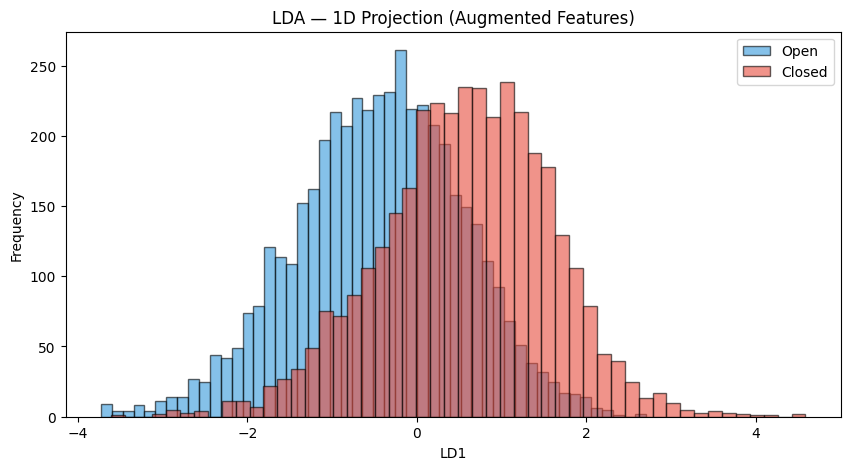

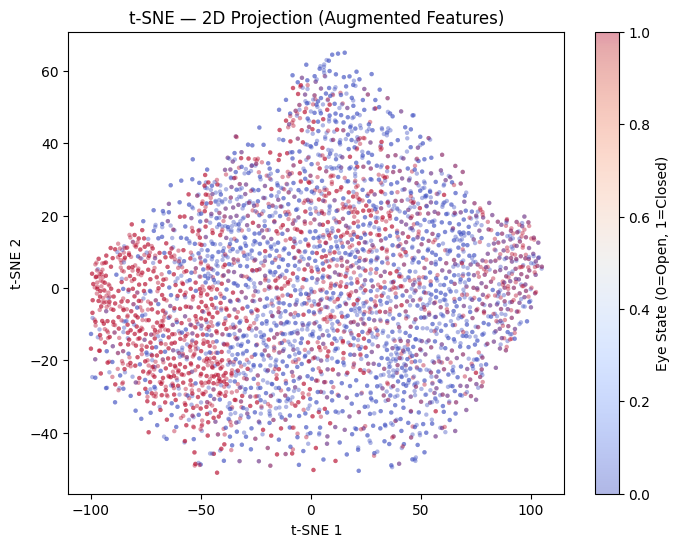

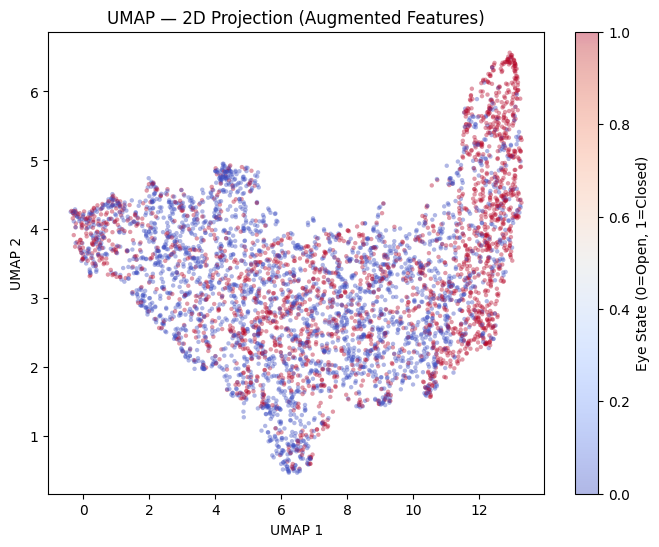

,Method,Silhouette,Davies-Bouldin,Calinski-Harabász
0,LDA (1D),0.1556,1.5464,2137.80
1,t-SNE (2D),0.0545,3.9085,269.92
2,UMAP (2D),0.0652,3.6491,297.92


In [12]:
def section_dim_reduction(df, all_features):
    X = df[all_features].values
    y = df[TARGET].values

    # IQR guard on the full feature matrix
    X_df = pd.DataFrame(X)
    Q1 = X_df.quantile(0.25); Q3 = X_df.quantile(0.75); IQR = Q3 - Q1
    mask = ~((X_df < Q1-1.5*IQR) | (X_df > Q3+1.5*IQR)).any(axis=1)
    X_clean = X_df[mask].values
    y_clean = y[mask]

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X_clean)

    # Rolling features + FFT augmentation
    window = 10
    X_roll_df   = pd.DataFrame(X_scaled)
    X_roll_mean = X_roll_df.rolling(window=window).mean().fillna(0).values
    X_roll_std  = X_roll_df.rolling(window=window).std().fillna(0).values
    X_fft       = np.abs(np.fft.fft(X_scaled, axis=0))
    X_features  = np.hstack([X_scaled, X_roll_mean, X_roll_std, X_fft])

    # LDA
    lda = LDA(n_components=1)
    X_lda = lda.fit_transform(X_features, y_clean)
    (fig, ax) = plt.subplots(figsize=(10, 5))
    for (label, color, name) in [(0,'#3498db','Open'),(1,'#e74c3c','Closed')]:
        ax.hist(X_lda[y_clean==label], bins=50, alpha=0.6,
                color=color, label=name, edgecolor='black')
    ax.set_title('LDA — 1D Projection (Augmented Features)')
    ax.set_xlabel('LD1'); ax.set_ylabel('Frequency'); ax.legend()
    save_fig('lda_1d_projection.png')

    # t-SNE
    n_tsne = min(5000, len(X_features))
    rng = np.random.RandomState(RANDOM_STATE)
    idx_sub = rng.choice(len(X_features), n_tsne, replace=False)
    X_sub = X_features[idx_sub]; y_sub = y_clean[idx_sub]
    tsne  = TSNE(n_components=2, perplexity=30,
                 random_state=RANDOM_STATE, max_iter=1000)
    X_tsne = tsne.fit_transform(X_sub)
    (fig, ax) = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(X_tsne[:,0], X_tsne[:,1], c=y_sub,
                          cmap='coolwarm', alpha=0.4, s=10, edgecolors='none')
    ax.set_title('t-SNE — 2D Projection (Augmented Features)')
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    plt.colorbar(scatter, label='Eye State (0=Open, 1=Closed)')
    save_fig('tsne_2d_projection.png')

    # UMAP (optional)
    X_umap = None
    if HAS_UMAP:
        umap_model = UMAP(n_components=2, n_neighbors=15,
                          min_dist=0.1, random_state=RANDOM_STATE)
        X_umap = umap_model.fit_transform(X_sub)
        (fig, ax) = plt.subplots(figsize=(8, 6))
        scatter = ax.scatter(X_umap[:,0], X_umap[:,1], c=y_sub,
                              cmap='coolwarm', alpha=0.4, s=10, edgecolors='none')
        ax.set_title('UMAP — 2D Projection (Augmented Features)')
        ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
        plt.colorbar(scatter, label='Eye State (0=Open, 1=Closed)')
        save_fig('umap_2d_projection.png')

    # Clustering quality metrics
    metrics_rows = []
    for (name_m, Xr, y_eval) in [
            ('LDA (1D)', np.column_stack([X_lda, np.zeros_like(X_lda)]), y_clean),
            ('t-SNE (2D)', X_tsne, y_sub)]:
        sil  = silhouette_score(Xr, y_eval)
        db   = davies_bouldin_score(Xr, y_eval)
        ch_s = calinski_harabasz_score(Xr, y_eval)
        metrics_rows.append([name_m, f'{sil:.4f}', f'{db:.4f}', f'{ch_s:.2f}'])
    if X_umap is not None:
        sil  = silhouette_score(X_umap, y_sub)
        db   = davies_bouldin_score(X_umap, y_sub)
        ch_s = calinski_harabasz_score(X_umap, y_sub)
        metrics_rows.append(['UMAP (2D)', f'{sil:.4f}', f'{db:.4f}', f'{ch_s:.2f}'])
    mdf = pd.DataFrame(metrics_rows,
                        columns=['Method','Silhouette','Davies-Bouldin','Calinski-Harabász'])
    display(mdf)

# ── Run section ─────────────────────────────────────────────────────────
progress('[9/12] Dimensionality reduction (LDA, t-SNE, UMAP) ...')
section_dim_reduction(df_eng, all_features)


## Prepare Arrays for Modelling

In [13]:
X_all = df_clean[FEATURE_COLUMNS].values.astype(np.float32)
y_all = df_clean[TARGET].values.astype(np.int64)
N = len(X_all)
print(f'X_all shape: {X_all.shape}  |  class balance: {y_all.mean():.2%} closed')


X_all shape: (13606, 14)  |  class balance: 45.32% closed


## Step 10 — Machine Learning Models

Temporal train/CV/test splits (70/15/15, 60/20/20, 80/10/10), walk-forward & sliding-window CV, threshold optimisation, feature importance, and ROC curves for: Logistic Regression, SVM-RBF, Random Forest, Gradient Boosting, XGBoost.


In [14]:
# ── Split & CV helpers ──────────────────────────────────────────────────

def temporal_three_way_split(X, y, train_frac, cv_frac):
    n = len(X)
    i1 = int(n * train_frac)
    i2 = int(n * (train_frac + cv_frac))
    return (X[:i1], y[:i1], X[i1:i2], y[i1:i2], X[i2:], y[i2:])

def walk_forward_cv_indices(n, n_folds=5, min_train_frac=0.5):
    min_tr = int(n * min_train_frac)
    step   = (n - min_tr) // (n_folds + 1)
    return [(slice(0, min_tr+k*step), slice(min_tr+k*step, min_tr+(k+1)*step))
            for k in range(n_folds)]

def sliding_window_cv_indices(n, n_folds=5, window_frac=0.5):
    win  = int(n * window_frac)
    step = (n - win) // (n_folds + 1)
    return [(slice(k*step, k*step+win),
             slice(k*step+win, min(k*step+win+step, n)))
            for k in range(n_folds)]

# ── Evaluation helpers ───────────────────────────────────────────────────

def _safe_auc(y_true, y_prob):
    try:
        return roc_auc_score(y_true, y_prob)
    except ValueError:
        return float('nan')

def _optimize_threshold(y_cv, probs_cv):
    (best_t, best_f1) = (0.5, 0.0)
    for t in np.arange(0.05, 0.96, 0.01):
        preds = (probs_cv >= t).astype(int)
        score = f1_score(y_cv, preds, average='macro', zero_division=0)
        if score > best_f1:
            (best_f1, best_t) = (score, float(t))
    return (best_t, best_f1)

def _evaluate_ml(y_true, y_pred, y_prob=None):
    acc  = accuracy_score(y_true, y_pred)
    mf1  = f1_score(y_true, y_pred, average='macro',  zero_division=0)
    bf1  = f1_score(y_true, y_pred, average='binary', zero_division=0)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro',    zero_division=0)
    auc  = _safe_auc(y_true, y_prob) if y_prob is not None else float('nan')
    return {'acc': acc, 'macro_f1': mf1, 'binary_f1': bf1,
            'precision': prec, 'recall': rec, 'auc': auc}

# ── Model factory ────────────────────────────────────────────────────────

def _get_ml_models(y_all):
    models = {
        'LogisticRegression': Pipeline([('sc', StandardScaler()),
            ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                                       solver='lbfgs', random_state=RANDOM_SEED))]),
        'SVM_RBF': Pipeline([('sc', StandardScaler()),
            ('clf', SVC(kernel='rbf', probability=True,
                        class_weight='balanced', random_state=RANDOM_SEED))]),
        'RandomForest': Pipeline([('sc', StandardScaler()),
            ('clf', RandomForestClassifier(n_estimators=200,
                        class_weight='balanced', n_jobs=-1, random_state=RANDOM_SEED))]),
        'GradientBoosting': Pipeline([('sc', StandardScaler()),
            ('clf', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                        max_depth=5, random_state=RANDOM_SEED))]),
    }
    if HAS_XGB:
        neg = int((y_all==0).sum()); pos = int((y_all==1).sum())
        models['XGBoost'] = Pipeline([('sc', StandardScaler()),
            ('clf', XGBClassifier(n_estimators=200, scale_pos_weight=neg/pos,
                                  eval_metric='logloss',
                                  random_state=RANDOM_SEED, n_jobs=-1))])
    return models

def _run_single_ml(name, model, X_tr, y_tr, X_cv, y_cv, X_te, y_te):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0
    cv_prob = model.predict_proba(X_cv)[:, 1]
    (opt_t, _) = _optimize_threshold(y_cv, cv_prob)
    results = {}
    for (part_name, Xs, ys) in [('CV', X_cv, y_cv), ('Test', X_te, y_te)]:
        prob   = model.predict_proba(Xs)[:, 1]
        thresh = opt_t if part_name == 'Test' else 0.5
        pred   = (prob >= thresh).astype(int)
        results[part_name] = _evaluate_ml(ys, pred, prob)
        results[part_name]['raw_prob'] = prob
        results[part_name]['pred']     = pred
    results['train_time'] = train_time
    results['opt_t']      = opt_t
    return results


[10/12] Training ML models ...

--- Split 70/15/15 ---


,Model,Acc,MacroF1,Precision,Recall,AUC,Threshold
0,LogisticRegression,0.7423,0.4540,0.4899,0.4639,0.3627,0.53
1,GradientBoosting,0.6781,0.4316,0.4879,0.4482,0.3968,0.65
2,RandomForest,0.6164,0.4009,0.4792,0.4021,0.3984,0.61
3,SVM_RBF,0.5987,0.3973,0.4815,0.4110,0.3736,0.64
4,XGBoost,0.5169,0.3710,0.4876,0.4361,0.4011,0.67



--- Split 60/20/20 ---


,Model,Acc,MacroF1,Precision,Recall,AUC,Threshold
0,LogisticRegression,0.7439,0.4812,0.5105,0.5379,0.4831,0.54
1,RandomForest,0.6323,0.4271,0.4968,0.4856,0.4515,0.68
2,GradientBoosting,0.6242,0.4200,0.4931,0.4681,0.4339,0.71
3,SVM_RBF,0.6102,0.4170,0.4952,0.4772,0.4691,0.71
4,XGBoost,0.5918,0.4149,0.5001,0.5006,0.5097,0.81



--- Split 80/10/10 ---


,Model,Acc,MacroF1,Precision,Recall,AUC,Threshold
0,GradientBoosting,0.9155,0.5251,0.5221,0.5313,0.4217,0.79
1,RandomForest,0.9030,0.5030,0.5039,0.5064,0.3742,0.73
2,XGBoost,0.9133,0.5015,0.5018,0.5025,0.3974,0.95
3,SVM_RBF,0.9214,0.4795,0.4801,0.4790,0.3734,0.84
4,LogisticRegression,0.8663,0.4642,0.4789,0.4503,0.2041,0.56



Walk-Forward CV:


,Model,MacroF1 (mean±std),Acc (mean±std)
0,LogisticRegression,0.6842±0.1868,0.8136±0.1818
1,SVM_RBF,0.6507±0.1769,0.8012±0.1831
2,RandomForest,0.6956±0.1978,0.7984±0.1964
3,GradientBoosting,0.6227±0.1684,0.8062±0.1972
4,XGBoost,0.5412±0.0281,0.7853±0.1737



Sliding-Window CV:


,Model,MacroF1 (mean±std)
0,LogisticRegression,0.6380±0.1882
1,SVM_RBF,0.6390±0.1838
2,RandomForest,0.6268±0.1877
3,GradientBoosting,0.5311±0.0259
4,XGBoost,0.5142±0.0309


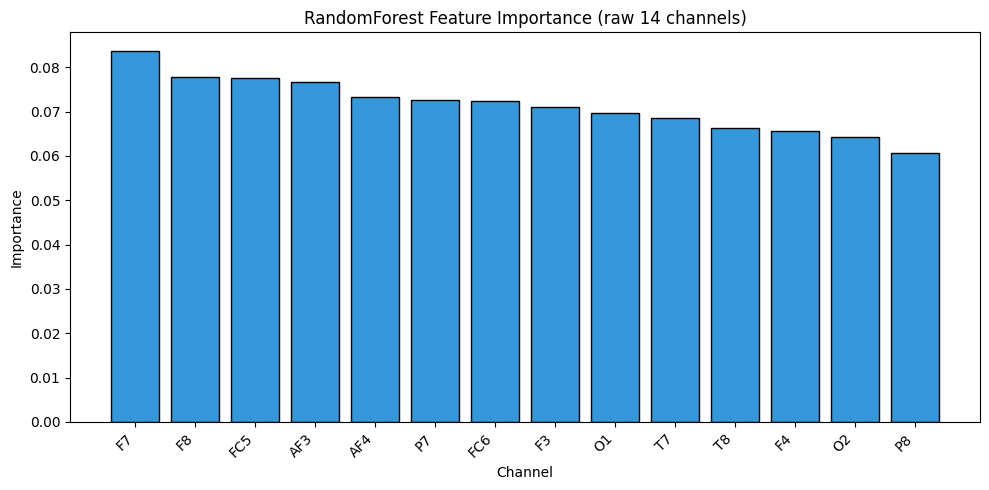

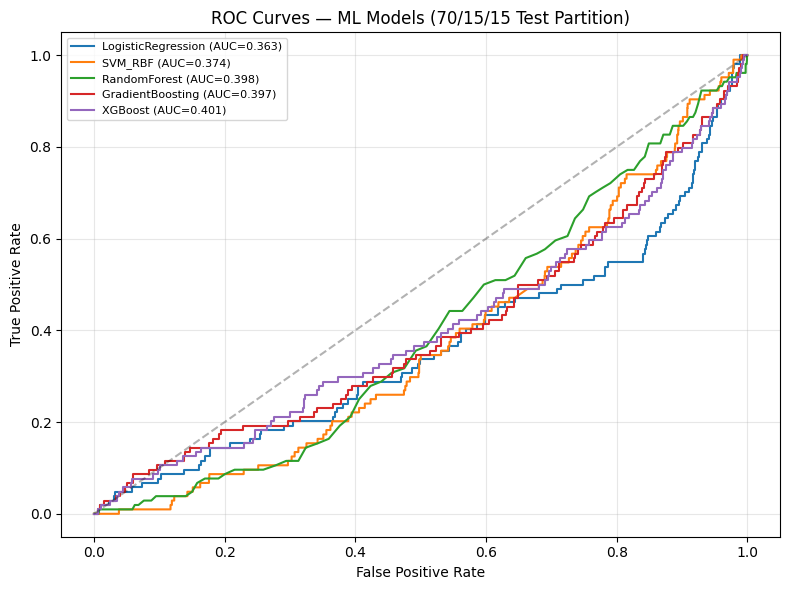

In [15]:
# ── section_ml ──────────────────────────────────────────────────────────

def section_ml(X_all, y_all, N):
    SPLIT_CONFIGS = [('70/15/15', 0.7, 0.15), ('60/20/20', 0.6, 0.2), ('80/10/10', 0.8, 0.1)]
    summary_rows_ml = []

    for (split_label, tr_frac, cv_frac) in SPLIT_CONFIGS:
        (X_tr, y_tr, X_cv, y_cv, X_te, y_te) = temporal_three_way_split(
            X_all, y_all, tr_frac, cv_frac)
        split_test_rows = []
        for (name, model) in _get_ml_models(y_all).items():
            res = _run_single_ml(name, model, X_tr, y_tr, X_cv, y_cv, X_te, y_te)
            te  = res['Test']
            split_test_rows.append([name, f"{te['acc']:.4f}",
                f"{te['macro_f1']:.4f}", f"{te['precision']:.4f}",
                f"{te['recall']:.4f}",   f"{te['auc']:.4f}",
                f"{res['opt_t']:.2f}"])
            summary_rows_ml.append({'split': split_label, 'model': name,
                **{k: v for (k,v) in te.items() if k not in ('raw_prob','pred')},
                'threshold': res['opt_t'], 'type': 'ML'})
        split_test_rows.sort(key=lambda r: float(r[2]), reverse=True)
        print(f'\n--- Split {split_label} ---')
        display(pd.DataFrame(split_test_rows,
            columns=['Model','Acc','MacroF1','Precision','Recall','AUC','Threshold']))

    # Walk-forward CV
    wf_agg = defaultdict(list)
    for (fi, (tr_sl, val_sl)) in enumerate(walk_forward_cv_indices(N)):
        for (name, model) in _get_ml_models(y_all).items():
            model.fit(X_all[tr_sl], y_all[tr_sl])
            prob  = model.predict_proba(X_all[val_sl])[:, 1]
            (opt_t, _) = _optimize_threshold(y_all[val_sl], prob)
            pred  = (prob >= opt_t).astype(int)
            m     = _evaluate_ml(y_all[val_sl], pred, prob)
            m['opt_t'] = opt_t
            wf_agg[name].append(m)
    wf_rows = [[n, f'{np.mean([f["macro_f1"] for f in folds]):.4f}±{np.std([f["macro_f1"] for f in folds]):.4f}',
                   f'{np.mean([f["acc"]      for f in folds]):.4f}±{np.std([f["acc"]      for f in folds]):.4f}']
               for (n, folds) in wf_agg.items()]
    print('\nWalk-Forward CV:')
    display(pd.DataFrame(wf_rows, columns=['Model','MacroF1 (mean±std)','Acc (mean±std)']))

    # Sliding-window CV
    sw_agg = defaultdict(list)
    for (fi, (tr_sl, val_sl)) in enumerate(sliding_window_cv_indices(N)):
        for (name, model) in _get_ml_models(y_all).items():
            model.fit(X_all[tr_sl], y_all[tr_sl])
            prob  = model.predict_proba(X_all[val_sl])[:, 1]
            (opt_t, _) = _optimize_threshold(y_all[val_sl], prob)
            pred  = (prob >= opt_t).astype(int)
            sw_agg[name].append(_evaluate_ml(y_all[val_sl], pred, prob))
    sw_rows = [[n, f'{np.mean([f["macro_f1"] for f in folds]):.4f}±{np.std([f["macro_f1"] for f in folds]):.4f}']
               for (n, folds) in sw_agg.items()]
    print('\nSliding-Window CV:')
    display(pd.DataFrame(sw_rows, columns=['Model','MacroF1 (mean±std)']))

    # Feature importance (Random Forest on 70% split)
    (X_tr70, y_tr70, _, _, _, _) = temporal_three_way_split(X_all, y_all, 0.7, 0.15)
    scaler_fi = StandardScaler()
    X_tr70_s  = scaler_fi.fit_transform(X_tr70)
    rf_fi = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                    n_jobs=-1, random_state=RANDOM_SEED)
    rf_fi.fit(X_tr70_s, y_tr70)
    importances = rf_fi.feature_importances_
    sorted_idx  = np.argsort(importances)[::-1]
    (fig, ax) = plt.subplots(figsize=(10, 5))
    ax.bar([FEATURE_COLUMNS[i] for i in sorted_idx],
           importances[sorted_idx], color='#3498db', edgecolor='black')
    ax.set_title('RandomForest Feature Importance (raw 14 channels)')
    ax.set_xlabel('Channel'); ax.set_ylabel('Importance')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    save_fig('ml_feature_importance.png')

    # ROC curves
    (X_tr70, y_tr70, X_cv70, y_cv70, X_te70, y_te70) = temporal_three_way_split(
        X_all, y_all, 0.7, 0.15)
    (fig, ax) = plt.subplots(figsize=(8, 6))
    for (name, model) in _get_ml_models(y_all).items():
        model.fit(X_tr70, y_tr70)
        y_prob  = model.predict_proba(X_te70)[:, 1]
        auc_val = _safe_auc(y_te70, y_prob)
        if not math.isnan(auc_val):
            (fpr, tpr, _) = roc_curve(y_te70, y_prob)
            ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', linewidth=1.5)
    ax.plot([0,1],[0,1],'k--',alpha=0.3)
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curves — ML Models (70/15/15 Test Partition)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig('ml_roc_curves.png')

    return summary_rows_ml

# ── Run section ─────────────────────────────────────────────────────────
progress('[10/12] Training ML models ...')
summary_rows_ml = section_ml(X_all, y_all, N)


## Step 11 — Deep Learning Models (PyTorch)

Five architectures trained with weighted cross-entropy + CosineAnnealingLR, then fused via a random-search ensemble optimiser:
- **LSTM** — stacked bidirectional LSTM
- **CNN-LSTM** — 1D-conv feature extractor + bidirectional LSTM
- **EEGTransformer** — CLS-token Transformer with sinusoidal PE
- **EEGNet** — depthwise/separable 2D-conv (Lawhern et al. 2018)
- **PatchTST-Lite** — patch-based Transformer (Nie et al. 2023)


In [16]:
# ── Sequence builder & DataLoader factory ───────────────────────────────

def build_sequences(X_flat, y_flat, seq_len):
    """(N, F) -> (M, seq_len, F) overlapping windows."""
    (Xs, ys) = ([], [])
    for i in range(len(X_flat) - seq_len):
        Xs.append(X_flat[i:i+seq_len])
        ys.append(y_flat[i+seq_len])
    return (np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.int64))

def make_dl_loaders(X_tr, y_tr, X_cv, y_cv, seq_len, batch):
    scaler   = StandardScaler()
    X_tr_s   = scaler.fit_transform(X_tr)
    X_cv_s   = scaler.transform(X_cv)
    (Xs_tr, ys_tr) = build_sequences(X_tr_s, y_tr, seq_len)
    (Xs_cv, ys_cv) = build_sequences(X_cv_s, y_cv, seq_len)
    (classes, counts) = np.unique(ys_tr, return_counts=True)
    class_weights = torch.tensor(
        [counts.sum()/(len(classes)*c) for c in counts], dtype=torch.float32)
    def to_loader(Xs, ys):
        return DataLoader(TensorDataset(torch.tensor(Xs), torch.tensor(ys)),
                          batch_size=batch, shuffle=False)
    return (to_loader(Xs_tr, ys_tr), to_loader(Xs_cv, ys_cv),
            scaler, class_weights, ys_cv)


In [17]:
# ── Model architectures ─────────────────────────────────────────────────

class LSTMClassifier(nn.Module):
    """Stacked bidirectional LSTM -> global average pool -> MLP head."""
    def __init__(self, n_features, hidden=128, n_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers=n_layers,
                             batch_first=True, dropout=dropout, bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(hidden*2, 64), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(64, 2))
    def forward(self, x):
        (out, _) = self.lstm(x)
        return self.head(out.mean(dim=1))


class CNNLSTMClassifier(nn.Module):
    """1-D conv feature extractor -> bidirectional LSTM -> classifier."""
    def __init__(self, n_features, dropout=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(n_features, 64, 3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.MaxPool1d(2))
        self.lstm = nn.LSTM(128, 64, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(128, 2))
    def forward(self, x):
        x = self.cnn(x.permute(0,2,1)).permute(0,2,1)
        (out, _) = self.lstm(x)
        return self.head(out.mean(dim=1))


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class EEGTransformer(nn.Module):
    """CLS token + sinusoidal PE + pre-LN TransformerEncoder -> MLP head."""
    def __init__(self, n_features, d_model=64, nhead=4, n_layers=3,
                 dim_ff=128, dropout=0.1, seq_len=64):
        super().__init__()
        self.proj    = nn.Linear(n_features, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=seq_len+1, dropout=dropout)
        enc = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, norm_first=True)
        self.tf        = nn.TransformerEncoder(enc, num_layers=n_layers)
        self.cls_token = nn.Parameter(torch.randn(1,1,d_model))
        self.head = nn.Sequential(
            nn.LayerNorm(d_model), nn.Linear(d_model, 32),
            nn.GELU(), nn.Dropout(dropout), nn.Linear(32, 2))
    def forward(self, x):
        B   = x.size(0)
        x   = self.proj(x)
        cls = self.cls_token.expand(B, -1, -1)
        x   = self.pos_enc(torch.cat([cls, x], dim=1))
        return self.head(self.tf(x)[:, 0])


class EEGNet(nn.Module):
    """
    EEGNet (Lawhern et al. 2018) — depthwise + separable 2D convolutions.
    Input: (B, T, C) -> (B, 1, C, T).
    """
    def __init__(self, n_channels=14, T=64, F1=8, D=2, dropout=0.25):
        super().__init__()
        F2     = F1 * D
        kern_t = T // 2
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, kern_t), padding=(0, kern_t//2), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F2, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F2), nn.ELU(), nn.AvgPool2d((1,4)), nn.Dropout(dropout))
        self.block2 = nn.Sequential(
            nn.Conv2d(F2, F2, (1,16), padding=(0,8), groups=F2, bias=False),
            nn.Conv2d(F2, F2, (1,1), bias=False),
            nn.BatchNorm2d(F2), nn.ELU(), nn.AvgPool2d((1,8)), nn.Dropout(dropout))
        self.flatten = nn.Flatten()
        with torch.no_grad():
            dummy   = torch.zeros(1,1,n_channels,T)
            flat_dim = self.flatten(self.block2(self.block1(dummy))).shape[1]
        self.head = nn.Linear(flat_dim, 2)
    def forward(self, x):
        x = x.permute(0,2,1).unsqueeze(1)
        return self.head(self.flatten(self.block2(self.block1(x))))


class PatchTST_Lite(nn.Module):
    """
    Lightweight PatchTST (Nie et al. 2023) — patch-based Transformer.
    Divides sequence into overlapping patches; CLS token aggregates context.
    """
    def __init__(self, n_features, seq_len=64, patch_size=8, stride=4,
                 d_model=64, nhead=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.patch_size = patch_size
        self.stride     = stride
        n_patches  = (seq_len - patch_size) // stride + 1
        patch_dim  = patch_size * n_features
        self.patch_proj = nn.Linear(patch_dim, d_model)
        self.cls_token  = nn.Parameter(torch.randn(1,1,d_model)*0.02)
        self.pos_embed  = nn.Parameter(torch.randn(1,n_patches+1,d_model)*0.02)
        self.drop = nn.Dropout(dropout)
        enc = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*2,
            dropout=dropout, batch_first=True, norm_first=True)
        self.tf   = nn.TransformerEncoder(enc, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model, 32), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(32, 2))
    def forward(self, x):
        B = x.size(0)
        patches = [x[:, i:i+self.patch_size, :].reshape(B,-1)
                   for i in range(0, x.size(1)-self.patch_size+1, self.stride)]
        x   = self.patch_proj(torch.stack(patches, dim=1))
        cls = self.cls_token.expand(B,-1,-1)
        x   = self.drop(torch.cat([cls, x], dim=1) + self.pos_embed)
        x   = self.norm(self.tf(x))
        return self.head(x[:, 0])


In [18]:
# ── Training & inference helpers ────────────────────────────────────────

def _train_epoch(model, loader, optimiser, criterion):
    model.train()
    total = 0.0
    for (Xb, yb) in loader:
        (Xb, yb) = (Xb.to(DEVICE), yb.to(DEVICE))
        optimiser.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()
        total += loss.item() * len(yb)
    return total / len(loader.dataset)

@torch.no_grad()
def _predict_dl(model, loader):
    model.eval()
    (preds, probs) = ([], [])
    for (Xb, _) in loader:
        logits = model(Xb.to(DEVICE))
        probs.append(torch.softmax(logits, 1)[:,1].cpu().numpy())
        preds.append(logits.argmax(1).cpu().numpy())
    return (np.concatenate(preds), np.concatenate(probs))

def _cv_loss(model, loader, criterion):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for (Xb, yb) in loader:
            (Xb, yb) = (Xb.to(DEVICE), yb.to(DEVICE))
            total += criterion(model(Xb), yb).item() * len(yb)
    return total / len(loader.dataset)

def _run_dl(name, model, tr_loader, cv_loader, y_cv_seq,
            X_te, y_te, scaler, seq_len, class_weights):
    model.to(DEVICE)
    cw        = class_weights.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=cw)
    optimiser = torch.optim.AdamW(model.parameters(),
                                   lr=DL_LR, weight_decay=0.0001)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimiser, T_max=DL_EPOCHS)
    train_losses, cv_losses = [], []
    for epoch in range(1, DL_EPOCHS+1):
        loss     = _train_epoch(model, tr_loader, optimiser, criterion)
        scheduler.step()
        train_losses.append(loss)
        val_loss = _cv_loss(model, cv_loader, criterion)
        cv_losses.append(val_loss)
        if epoch % 5 == 0:
            (cv_preds, _) = _predict_dl(model, cv_loader)
            mf1 = f1_score(y_cv_seq, cv_preds, average='macro', zero_division=0)
            print(f'  {name} epoch {epoch:3d} | train={loss:.4f} cv={val_loss:.4f} f1={mf1:.4f}')
    (fig, ax) = plt.subplots(figsize=(8, 4))
    ax.plot(range(1,DL_EPOCHS+1), train_losses, label='Train Loss',
            color='#3498db', linewidth=1.5)
    ax.plot(range(1,DL_EPOCHS+1), cv_losses,    label='CV Loss',
            color='#e74c3c', linewidth=1.5)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title(f'{name} — Train vs CV Loss')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig(f'dl_loss_curve_{name.lower()}.png')

    (cv_preds, cv_probs) = _predict_dl(model, cv_loader)
    (opt_t, _) = _optimize_threshold(y_cv_seq, cv_probs)
    cv_res = _evaluate_ml(y_cv_seq, (cv_probs>=opt_t).astype(int), cv_probs)

    X_te_s = scaler.transform(X_te)
    (Xs_te, ys_te) = build_sequences(X_te_s, y_te, seq_len)
    te_loader = DataLoader(TensorDataset(torch.tensor(Xs_te), torch.tensor(ys_te)),
                           batch_size=DL_BATCH, shuffle=False)
    (te_preds, te_probs) = _predict_dl(model, te_loader)
    te_res = _evaluate_ml(ys_te, (te_probs>=opt_t).astype(int), te_probs)
    te_res['pred']     = (te_probs>=opt_t).astype(int)
    te_res['raw_prob'] = te_probs
    return {'CV': cv_res, 'Test': te_res, 'opt_t': opt_t,
            'y_te_seq': ys_te, 'te_probs': te_probs}


# ── Ensemble optimiser ───────────────────────────────────────────────────

class EnsembleOptimizer:
    def __init__(self):
        self.best_weights = None
        self.model_names  = []

    def optimize(self, probs_cv_dict, y_cv, n_trials=ENS_TRIALS):
        self.model_names = list(probs_cv_dict.keys())
        k        = len(self.model_names)
        prob_mat = np.column_stack([probs_cv_dict[n] for n in self.model_names])
        def eval_w(w):
            preds = (prob_mat @ w >= 0.5).astype(int)
            return f1_score(y_cv, preds, average='macro', zero_division=0)
        rng    = np.random.RandomState(RANDOM_SEED)
        best_w = np.ones(k)/k
        best_f1 = eval_w(best_w)
        for _ in range(n_trials):
            w = rng.dirichlet(np.ones(k))
            s = eval_w(w)
            if s > best_f1:
                (best_f1, best_w) = (s, w.copy())
        self.best_weights = best_w
        return (dict(zip(self.model_names, best_w.tolist())), best_f1)

    def predict(self, probs_test_dict, threshold=0.5):
        prob_mat = np.column_stack([probs_test_dict[n] for n in self.model_names])
        ens_prob = prob_mat @ self.best_weights
        return ((ens_prob >= threshold).astype(int), ens_prob)


[11/12] Training DL models (PyTorch) ...

=== Split 70/15/15 ===
  Training LSTM ...
  LSTM epoch   5 | train=0.7117 cv=0.8391 f1=0.3322
  LSTM epoch  10 | train=0.6028 cv=2.1450 f1=0.3825
  LSTM epoch  15 | train=0.2375 cv=2.5196 f1=0.5725
  LSTM epoch  20 | train=0.0842 cv=2.7426 f1=0.5991
  LSTM epoch  25 | train=0.0436 cv=2.8634 f1=0.6035


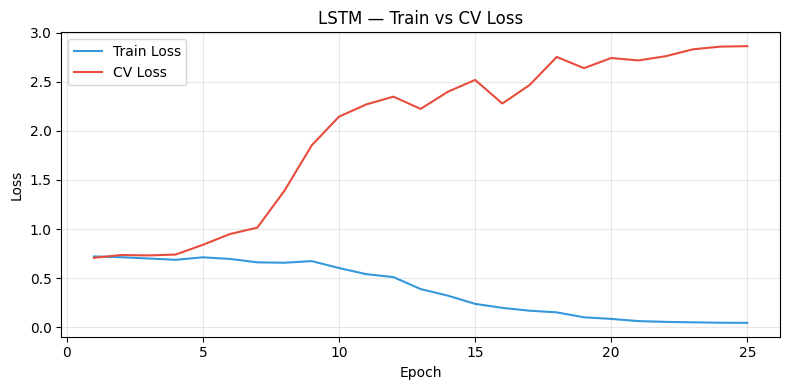

  Training CNN_LSTM ...
  CNN_LSTM epoch   5 | train=0.6949 cv=0.9707 f1=0.2774
  CNN_LSTM epoch  10 | train=0.5413 cv=1.7272 f1=0.4258
  CNN_LSTM epoch  15 | train=0.2671 cv=1.9697 f1=0.5355
  CNN_LSTM epoch  20 | train=0.0601 cv=2.5006 f1=0.4947
  CNN_LSTM epoch  25 | train=0.0280 cv=2.3453 f1=0.4915


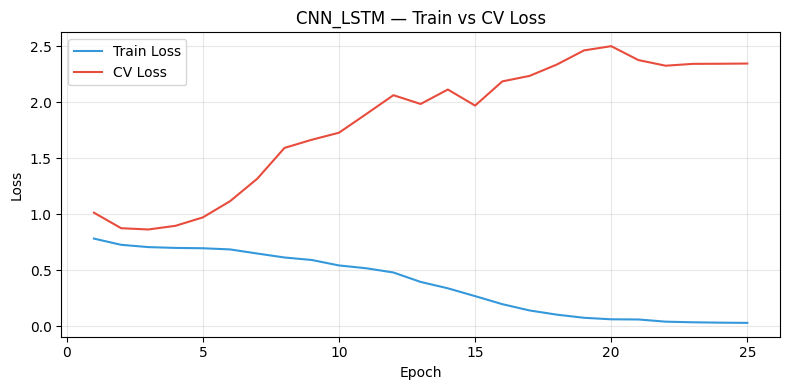

  Training EEGTransformer ...
  EEGTransformer epoch   5 | train=0.6995 cv=0.7850 f1=0.2702
  EEGTransformer epoch  10 | train=0.6927 cv=0.7586 f1=0.2702
  EEGTransformer epoch  15 | train=0.6899 cv=0.7507 f1=0.2702
  EEGTransformer epoch  20 | train=0.8597 cv=1.3001 f1=0.2702
  EEGTransformer epoch  25 | train=0.9075 cv=1.3559 f1=0.2702


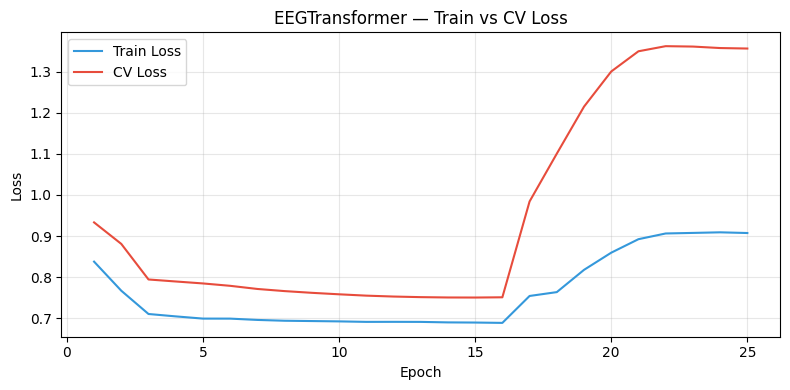

  Training EEGNet ...
  EEGNet epoch   5 | train=0.6915 cv=0.7915 f1=0.2691
  EEGNet epoch  10 | train=0.6844 cv=0.8005 f1=0.2697
  EEGNet epoch  15 | train=0.6762 cv=0.8093 f1=0.2661
  EEGNet epoch  20 | train=0.6714 cv=0.8185 f1=0.2653
  EEGNet epoch  25 | train=0.6679 cv=0.8204 f1=0.2653


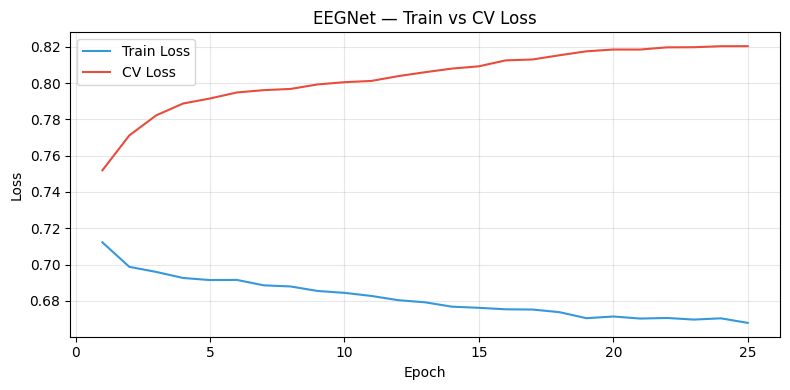

  Training PatchTST_Lite ...
  PatchTST_Lite epoch   5 | train=0.9123 cv=1.4212 f1=0.3557
  PatchTST_Lite epoch  10 | train=0.6795 cv=1.6607 f1=0.3389
  PatchTST_Lite epoch  15 | train=0.4424 cv=1.8226 f1=0.3944
  PatchTST_Lite epoch  20 | train=0.2351 cv=1.5375 f1=0.5741
  PatchTST_Lite epoch  25 | train=0.1746 cv=1.6094 f1=0.5736


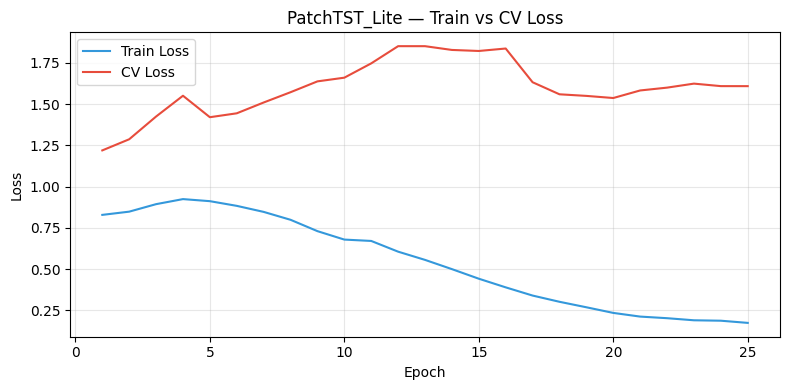

  Ensemble CV F1: 0.6035  weights: LSTM=0.883  CNN_LSTM=0.070  EEGTransformer=0.024  EEGNet=0.018  PatchTST_Lite=0.004


,Model,Acc,MacroF1,Precision,Recall,AUC,Threshold
0,EEGNet,0.6859,0.4977,0.5433,0.6935,0.7597,0.65
1,Ensemble,0.6874,0.4852,0.5309,0.6352,0.6511,0.92
2,CNN_LSTM,0.7086,0.4837,0.5224,0.5920,0.7119,0.82
3,LSTM,0.5655,0.4177,0.5152,0.5754,0.5908,0.92
4,EEGTransformer,0.6146,0.3806,0.4606,0.3243,0.1221,0.89
5,PatchTST_Lite,0.3728,0.2820,0.4534,0.2739,0.2221,0.95



=== Split 60/20/20 ===
  Training LSTM ...
  LSTM epoch   5 | train=1.0350 cv=1.8232 f1=0.2699
  LSTM epoch  10 | train=0.7972 cv=1.6416 f1=0.3871
  LSTM epoch  15 | train=0.5617 cv=1.3906 f1=0.5163
  LSTM epoch  20 | train=0.3462 cv=1.5315 f1=0.5520
  LSTM epoch  25 | train=0.2800 cv=1.6976 f1=0.5175


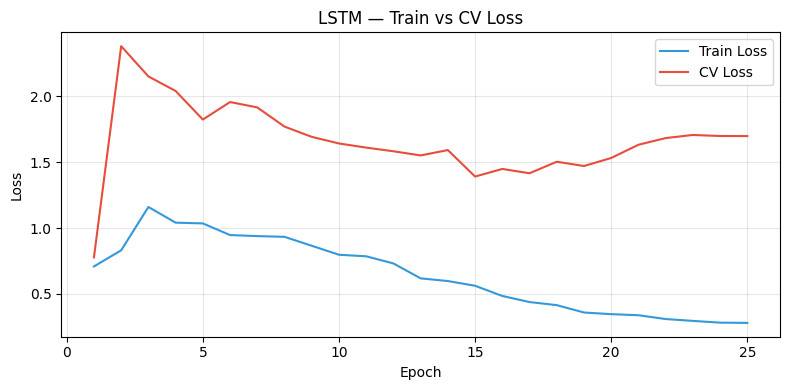

  Training CNN_LSTM ...
  CNN_LSTM epoch   5 | train=0.8220 cv=1.5726 f1=0.2482
  CNN_LSTM epoch  10 | train=0.6006 cv=1.7636 f1=0.3645
  CNN_LSTM epoch  15 | train=0.3496 cv=1.7242 f1=0.4708
  CNN_LSTM epoch  20 | train=0.1450 cv=1.8007 f1=0.4673
  CNN_LSTM epoch  25 | train=0.0682 cv=1.7220 f1=0.4795


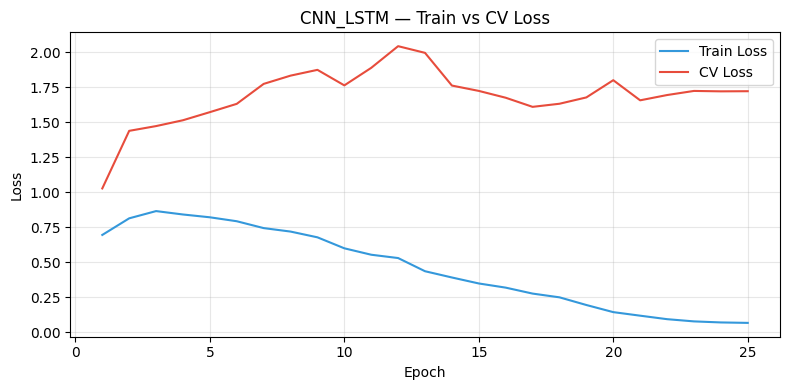

  Training EEGTransformer ...
  EEGTransformer epoch   5 | train=1.0603 cv=1.9380 f1=0.2482
  EEGTransformer epoch  10 | train=1.0433 cv=1.7893 f1=0.2482
  EEGTransformer epoch  15 | train=0.9334 cv=1.7216 f1=0.2730
  EEGTransformer epoch  20 | train=0.8789 cv=1.7589 f1=0.2690
  EEGTransformer epoch  25 | train=0.8492 cv=1.7772 f1=0.2652


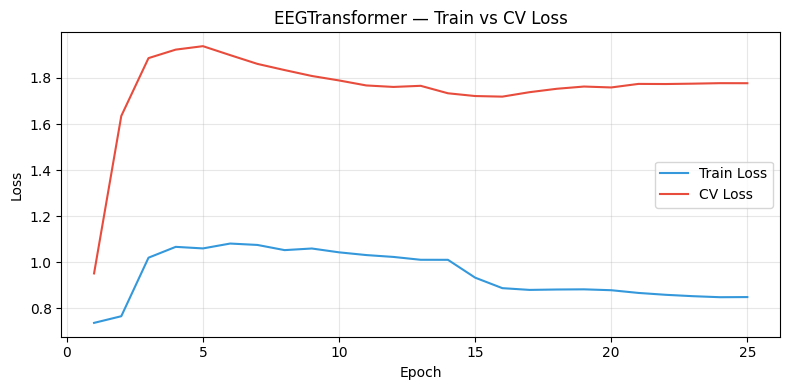

  Training EEGNet ...
  EEGNet epoch   5 | train=0.6974 cv=0.9759 f1=0.2482
  EEGNet epoch  10 | train=0.7390 cv=1.1129 f1=0.2482
  EEGNet epoch  15 | train=0.7447 cv=1.1617 f1=0.2482
  EEGNet epoch  20 | train=0.7390 cv=1.1925 f1=0.2482
  EEGNet epoch  25 | train=0.7396 cv=1.2022 f1=0.2482


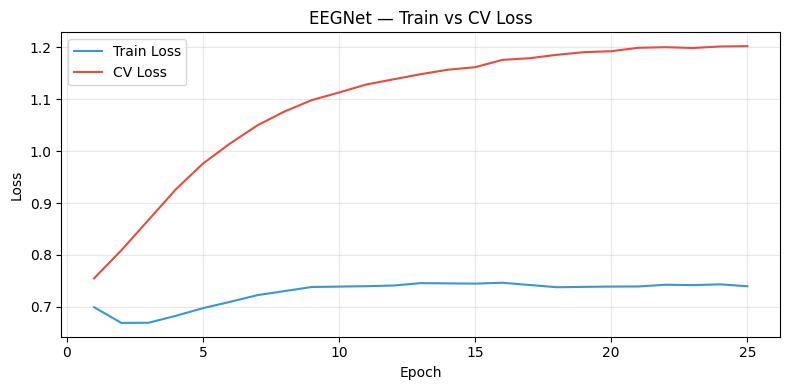

  Training PatchTST_Lite ...
  PatchTST_Lite epoch   5 | train=1.0838 cv=1.9968 f1=0.2711
  PatchTST_Lite epoch  10 | train=0.9276 cv=1.9117 f1=0.2980
  PatchTST_Lite epoch  15 | train=0.7583 cv=1.6984 f1=0.4250
  PatchTST_Lite epoch  20 | train=0.5604 cv=1.6806 f1=0.4608
  PatchTST_Lite epoch  25 | train=0.4658 cv=1.6944 f1=0.4637


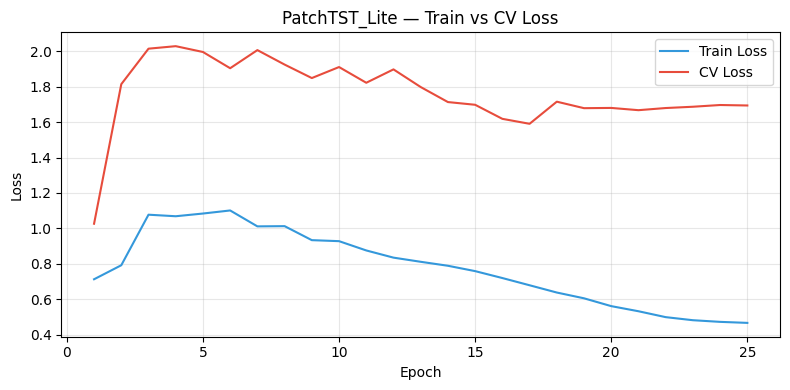

  Ensemble CV F1: 0.5446  weights: LSTM=0.464  CNN_LSTM=0.491  EEGTransformer=0.016  EEGNet=0.002  PatchTST_Lite=0.027


,Model,Acc,MacroF1,Precision,Recall,AUC,Threshold
0,EEGNet,0.6791,0.5047,0.5523,0.7348,0.8272,0.84
1,EEGTransformer,0.9462,0.4862,0.4731,0.5000,0.3469,0.93
2,LSTM,0.5478,0.4096,0.5143,0.5698,0.6290,0.95
3,CNN_LSTM,0.5060,0.3871,0.5111,0.5543,0.6093,0.93
4,Ensemble,0.3657,0.3099,0.5112,0.5494,0.6090,0.53
5,PatchTST_Lite,0.3604,0.2833,0.4638,0.3323,0.2878,0.95



=== Split 80/10/10 ===
  Training LSTM ...
  LSTM epoch   5 | train=0.6992 cv=0.7692 f1=0.1119
  LSTM epoch  10 | train=0.7756 cv=1.3516 f1=0.2420
  LSTM epoch  15 | train=0.3631 cv=1.3942 f1=0.4017
  LSTM epoch  20 | train=0.1039 cv=2.9515 f1=0.3349
  LSTM epoch  25 | train=0.0627 cv=3.2704 f1=0.3371


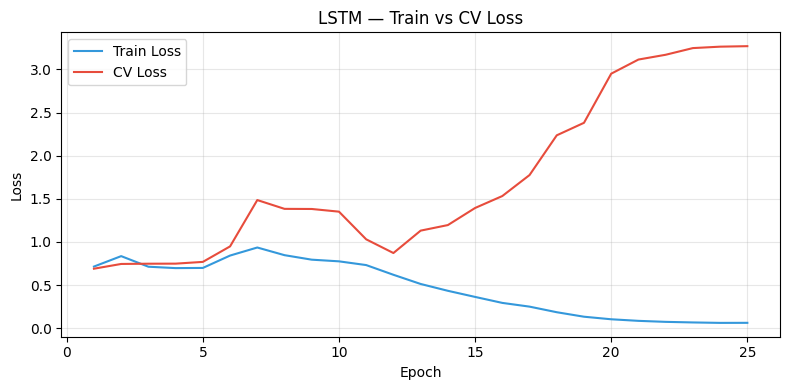

  Training CNN_LSTM ...
  CNN_LSTM epoch   5 | train=0.7110 cv=0.9541 f1=0.0803
  CNN_LSTM epoch  10 | train=0.5800 cv=0.8587 f1=0.4947
  CNN_LSTM epoch  15 | train=0.2383 cv=1.4109 f1=0.4965
  CNN_LSTM epoch  20 | train=0.0610 cv=2.1480 f1=0.4347
  CNN_LSTM epoch  25 | train=0.0239 cv=1.7645 f1=0.4878


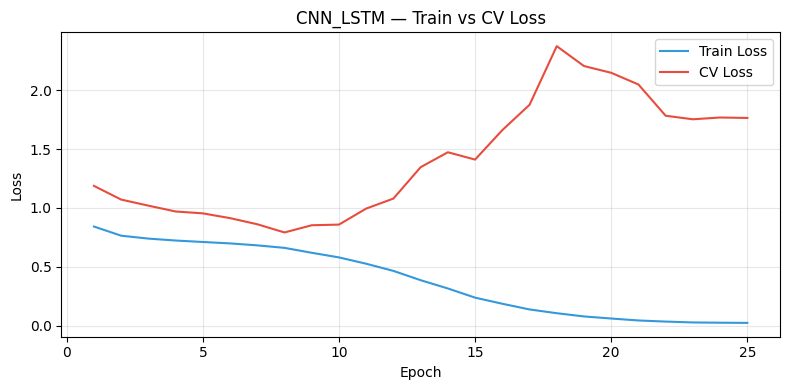

  Training EEGTransformer ...
  EEGTransformer epoch   5 | train=1.0923 cv=2.1024 f1=0.0656
  EEGTransformer epoch  10 | train=1.0448 cv=2.0196 f1=0.0656
  EEGTransformer epoch  15 | train=1.0107 cv=1.9570 f1=0.0656
  EEGTransformer epoch  20 | train=0.8372 cv=1.5798 f1=0.1910
  EEGTransformer epoch  25 | train=0.7395 cv=1.6594 f1=0.1882


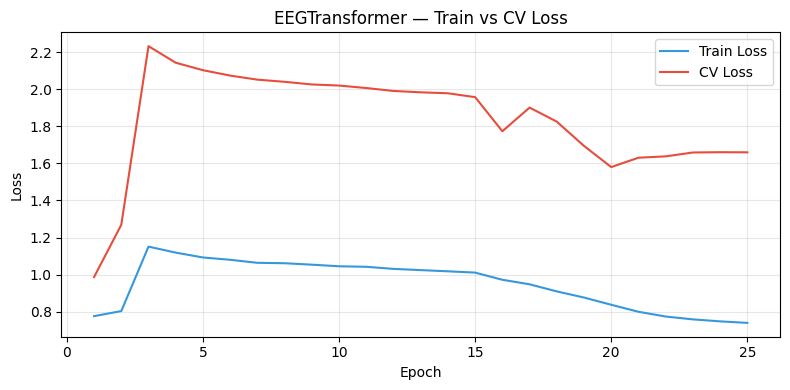

  Training EEGNet ...
  EEGNet epoch   5 | train=0.7007 cv=0.9166 f1=0.0664
  EEGNet epoch  10 | train=0.6924 cv=0.9365 f1=0.0656
  EEGNet epoch  15 | train=0.6895 cv=0.9604 f1=0.0656
  EEGNet epoch  20 | train=0.6848 cv=0.9841 f1=0.0656
  EEGNet epoch  25 | train=0.6822 cv=0.9905 f1=0.0656


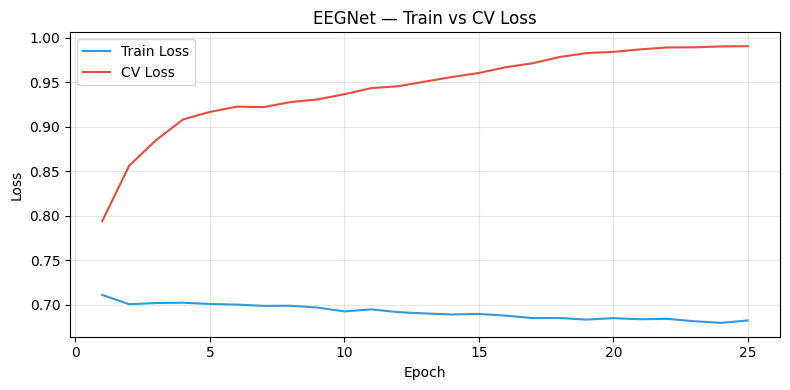

  Training PatchTST_Lite ...
  PatchTST_Lite epoch   5 | train=0.9414 cv=1.7318 f1=0.1121
  PatchTST_Lite epoch  10 | train=0.7697 cv=1.7817 f1=0.1528
  PatchTST_Lite epoch  15 | train=0.5201 cv=1.9635 f1=0.1862
  PatchTST_Lite epoch  20 | train=0.3410 cv=1.7331 f1=0.2944
  PatchTST_Lite epoch  25 | train=0.2667 cv=1.8430 f1=0.2994


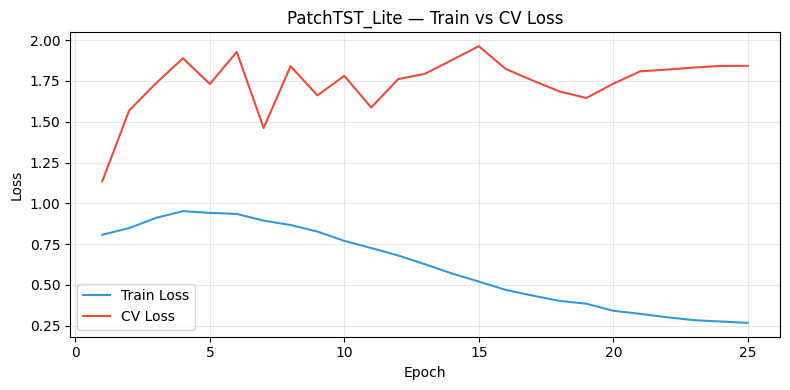

  Ensemble CV F1: 0.4879  weights: LSTM=0.029  CNN_LSTM=0.777  EEGTransformer=0.016  EEGNet=0.089  PatchTST_Lite=0.090


,Model,Acc,MacroF1,Precision,Recall,AUC,Threshold
0,CNN_LSTM,0.7641,0.5323,0.5520,0.7573,0.7869,0.94
1,EEGTransformer,0.9599,0.4898,0.4800,0.5000,0.0373,0.90
2,EEGNet,0.9152,0.4868,0.4877,0.4859,0.5003,0.84
3,Ensemble,0.8705,0.4712,0.4826,0.4626,0.7619,0.95
4,LSTM,0.5281,0.4055,0.5335,0.7174,0.6222,0.95
5,PatchTST_Lite,0.4564,0.3252,0.4738,0.3299,0.2768,0.95


In [19]:
# ── section_dl ──────────────────────────────────────────────────────────

def section_dl(X_all, y_all):
    SPLIT_CONFIGS = [('70/15/15',0.7,0.15),('60/20/20',0.6,0.2),('80/10/10',0.8,0.1)]
    N_FEATURES    = len(FEATURE_COLUMNS)
    summary_rows_dl = []
    dl_model_factories = {
        'LSTM':         lambda: LSTMClassifier(N_FEATURES),
        'CNN_LSTM':     lambda: CNNLSTMClassifier(N_FEATURES),
        'EEGTransformer': lambda: EEGTransformer(N_FEATURES, d_model=64, nhead=4,
                                                  n_layers=3, seq_len=SEQ_LEN),
        'EEGNet':       lambda: EEGNet(n_channels=N_FEATURES, T=SEQ_LEN),
        'PatchTST_Lite': lambda: PatchTST_Lite(N_FEATURES, seq_len=SEQ_LEN,
                                                patch_size=PATCH_SIZE, stride=PATCH_STRIDE),
    }
    for (split_label, tr_frac, cv_frac) in SPLIT_CONFIGS:
        print(f'\n=== Split {split_label} ===')
        (X_tr, y_tr, X_cv, y_cv, X_te, y_te) = temporal_three_way_split(
            X_all, y_all, tr_frac, cv_frac)
        dl_cv_probs = {}; dl_te_probs = {}; y_te_seq_ref = None
        split_dl_rows = []
        for arch_name in dl_model_factories:
            print(f'  Training {arch_name} ...')
            (tr_loader, cv_loader, scaler, cw, y_cv_seq) = make_dl_loaders(
                X_tr, y_tr, X_cv, y_cv, SEQ_LEN, DL_BATCH)
            model = dl_model_factories[arch_name]()
            res   = _run_dl(arch_name, model, tr_loader, cv_loader,
                            y_cv_seq, X_te, y_te, scaler, SEQ_LEN, cw)
            (_, cv_p) = _predict_dl(model, cv_loader)
            dl_cv_probs[arch_name] = cv_p
            dl_te_probs[arch_name] = res['te_probs']
            if y_te_seq_ref is None:
                y_te_seq_ref = res['y_te_seq']
            te = res['Test']
            split_dl_rows.append([arch_name, f"{te['acc']:.4f}",
                f"{te['macro_f1']:.4f}", f"{te['precision']:.4f}",
                f"{te['recall']:.4f}",   f"{te['auc']:.4f}",
                f"{res['opt_t']:.2f}"])
            summary_rows_dl.append({'split': split_label, 'model': arch_name,
                **{k: v for (k,v) in te.items() if k not in ('raw_prob','pred')},
                'threshold': res['opt_t'], 'type': 'DL'})

        # Ensemble
        y_cv_ens = y_cv[SEQ_LEN:]
        y_te_ens = y_te_seq_ref
        ens = EnsembleOptimizer()
        (best_weights, cv_ens_f1) = ens.optimize(dl_cv_probs, y_cv_ens)
        print(f'  Ensemble CV F1: {cv_ens_f1:.4f}  weights: '
              + '  '.join(f'{m}={w:.3f}' for (m,w) in best_weights.items()))
        ens_cv_prob_vec = (np.column_stack([dl_cv_probs[n] for n in ens.model_names])
                           @ ens.best_weights)
        (opt_t_ens, _) = _optimize_threshold(y_cv_ens, ens_cv_prob_vec)
        (te_ens_pred, te_ens_prob) = ens.predict(dl_te_probs, threshold=opt_t_ens)
        ens_res = _evaluate_ml(y_te_ens, te_ens_pred, te_ens_prob)
        split_dl_rows.append(['Ensemble', f"{ens_res['acc']:.4f}",
            f"{ens_res['macro_f1']:.4f}", f"{ens_res['precision']:.4f}",
            f"{ens_res['recall']:.4f}",   f"{ens_res['auc']:.4f}",
            f'{opt_t_ens:.2f}'])
        summary_rows_dl.append({'split': split_label, 'model': 'Ensemble',
            **ens_res, 'threshold': opt_t_ens, 'type': 'DL'})
        split_dl_rows.sort(key=lambda r: float(r[2]), reverse=True)
        display(pd.DataFrame(split_dl_rows,
            columns=['Model','Acc','MacroF1','Precision','Recall','AUC','Threshold']))

    return summary_rows_dl

# ── Run section ─────────────────────────────────────────────────────────
progress('[11/12] Training DL models (PyTorch) ...')
summary_rows_dl = section_dl(X_all, y_all)


## Step 12 — Final Comparison

Side-by-side Accuracy / MacroF1 / AUC bar charts across all models and splits, plus best-per-split and overall ranking tables.


[12/12] Generating final comparison ...

=== 70/15/15 ===


,model,type,acc,macro_f1,precision,recall,auc,threshold
0,EEGNet,DL,0.685888,0.497749,0.543257,0.693460,0.759662,0.65
1,Ensemble,DL,0.687405,0.485219,0.530937,0.635231,0.651115,0.92
2,CNN_LSTM,DL,0.708649,0.483677,0.522381,0.591954,0.711862,0.82
3,LogisticRegression,ML,0.742283,0.454043,0.489896,0.463862,0.362744,0.53
4,GradientBoosting,ML,0.678099,0.431649,0.487858,0.448245,0.396807,0.65
5,LSTM,DL,0.565503,0.417715,0.515232,0.575437,0.590763,0.92
6,RandomForest,ML,0.616365,0.400900,0.479165,0.402072,0.398361,0.61
7,SVM_RBF,ML,0.598726,0.397256,0.481550,0.410977,0.373590,0.64
8,EEGTransformer,DL,0.614568,0.380639,0.460576,0.324346,0.122120,0.89
9,XGBoost,ML,0.516903,0.370997,0.487589,0.436113,0.401116,0.67



=== 60/20/20 ===


,model,type,acc,macro_f1,precision,recall,auc,threshold
0,EEGNet,DL,0.679082,0.504750,0.552337,0.734784,0.827168,0.84
1,EEGTransformer,DL,0.946200,0.486178,0.473100,0.500000,0.346888,0.93
2,LogisticRegression,ML,0.743938,0.481249,0.510470,0.537910,0.483095,0.54
3,RandomForest,ML,0.632256,0.427055,0.496840,0.485577,0.451468,0.68
4,GradientBoosting,ML,0.624173,0.420002,0.493058,0.468102,0.433897,0.71
5,SVM_RBF,ML,0.610213,0.417004,0.495151,0.477248,0.469079,0.71
6,XGBoost,ML,0.591844,0.414864,0.500121,0.500580,0.509652,0.81
7,LSTM,DL,0.547780,0.409570,0.514287,0.569767,0.628973,0.95
8,CNN_LSTM,DL,0.506020,0.387052,0.511057,0.554295,0.609279,0.93
9,Ensemble,DL,0.365688,0.309858,0.511233,0.549392,0.608962,0.53



=== 80/10/10 ===


,model,type,acc,macro_f1,precision,recall,auc,threshold
0,CNN_LSTM,DL,0.764071,0.532332,0.551999,0.757329,0.786917,0.94
1,GradientBoosting,ML,0.915503,0.525086,0.522115,0.531336,0.421725,0.79
2,RandomForest,ML,0.903012,0.503010,0.503874,0.506376,0.374243,0.73
3,XGBoost,ML,0.913299,0.501484,0.501826,0.502490,0.397353,0.95
4,EEGTransformer,DL,0.959907,0.489772,0.479954,0.500000,0.037257,0.90
5,EEGNet,DL,0.915189,0.486769,0.487719,0.485921,0.500263,0.84
6,SVM_RBF,ML,0.921381,0.479541,0.480092,0.478992,0.373362,0.84
7,Ensemble,DL,0.870470,0.471229,0.482609,0.462627,0.761940,0.95
8,LogisticRegression,ML,0.866275,0.464173,0.478879,0.450344,0.204134,0.56
9,LSTM,DL,0.528142,0.405548,0.533465,0.717362,0.622212,0.95


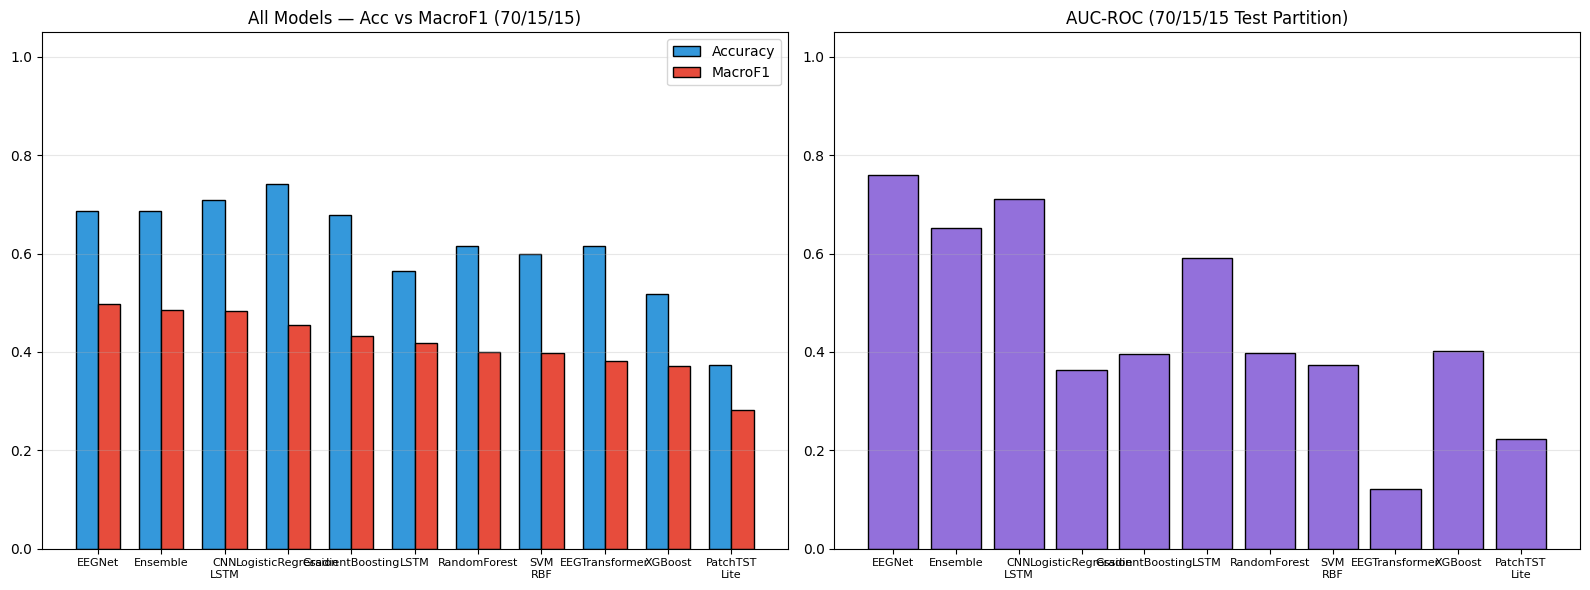


=== Best model per split ===


,Split,Model,Type,MacroF1,Acc,AUC
0,70/15/15,EEGNet,DL,0.4977,0.6859,0.7597
1,60/20/20,EEGNet,DL,0.5047,0.6791,0.8272
2,80/10/10,CNN_LSTM,DL,0.5323,0.7641,0.7869



=== Overall mean MacroF1 ranking ===


,model,Mean MacroF1
0,EEGNet,0.496423
1,CNN_LSTM,0.467687
2,LogisticRegression,0.466488
3,GradientBoosting,0.458912
4,EEGTransformer,0.452196
5,RandomForest,0.443655
6,SVM_RBF,0.431267
7,XGBoost,0.429115
8,Ensemble,0.422102
9,LSTM,0.410944



Best overall model: EEGNet  (mean MacroF1=0.4964)
Pipeline complete.


In [20]:
def section_final_comparison(summary_rows_ml, summary_rows_dl):
    all_rows = summary_rows_ml + summary_rows_dl
    df_sum   = pd.DataFrame(all_rows)

    for split_label in ['70/15/15', '60/20/20', '80/10/10']:
        sub = df_sum[df_sum['split']==split_label].copy()
        sub = sub.sort_values('macro_f1', ascending=False)
        print(f'\n=== {split_label} ===')
        display(sub[['model','type','acc','macro_f1',
                       'precision','recall','auc','threshold']].reset_index(drop=True))

    # Bar chart
    sub70 = df_sum[df_sum['split']=='70/15/15'].sort_values('macro_f1', ascending=False)
    if not sub70.empty:
        (fig, axes) = plt.subplots(1, 2, figsize=(16, 6))
        names = sub70['model'].tolist()
        x = np.arange(len(names)); w = 0.35
        axes[0].bar(x-w/2, sub70['acc'].tolist(),      w,
                    label='Accuracy', color='#3498db', edgecolor='black')
        axes[0].bar(x+w/2, sub70['macro_f1'].tolist(), w,
                    label='MacroF1',  color='#e74c3c', edgecolor='black')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels([n.replace('_','\n') for n in names], fontsize=8)
        axes[0].set_ylim(0, 1.05)
        axes[0].set_title('All Models — Acc vs MacroF1 (70/15/15)')
        axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')
        aucs = [v if not math.isnan(v) else 0.0 for v in sub70['auc'].tolist()]
        axes[1].bar(names, aucs, color='#9370DB', edgecolor='black')
        axes[1].set_xticklabels([n.replace('_','\n') for n in names], fontsize=8)
        axes[1].set_ylim(0, 1.05)
        axes[1].set_title('AUC-ROC (70/15/15 Test Partition)')
        axes[1].grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        save_fig('final_comparison.png')

    # Best per split
    best_per_split = []
    for split_label in ['70/15/15', '60/20/20', '80/10/10']:
        sub = df_sum[df_sum['split']==split_label]
        if sub.empty: continue
        best = sub.loc[sub['macro_f1'].idxmax()]
        best_per_split.append([split_label, best['model'], best.get('type','?'),
                                f"{best['macro_f1']:.4f}", f"{best['acc']:.4f}",
                                f"{best.get('auc', float('nan')):.4f}"])
    print('\n=== Best model per split ===')
    display(pd.DataFrame(best_per_split,
        columns=['Split','Model','Type','MacroF1','Acc','AUC']))

    # Overall mean ranking
    mean_mf1 = df_sum.groupby('model')['macro_f1'].mean().sort_values(ascending=False)
    print('\n=== Overall mean MacroF1 ranking ===')
    display(mean_mf1.reset_index().rename(columns={'macro_f1':'Mean MacroF1'}))
    best_overall = mean_mf1.index[0]
    print(f'\nBest overall model: {best_overall}  (mean MacroF1={mean_mf1.iloc[0]:.4f})')

# ── Run section ─────────────────────────────────────────────────────────
progress('[12/12] Generating final comparison ...')
section_final_comparison(summary_rows_ml, summary_rows_dl)
progress('Pipeline complete.')
